In [2]:
import scanpy as sc

In [3]:
adata = sc.read_h5ad('../data/ST_BRICHOS_region_subcluster.h5ad')

In [4]:
adata.obs['condition'] = adata.obs['treatment']

In [5]:
adata.obs['condition']

AAACAAGTATCTCCCA-1-P24215_301    BRICHOS
AAACAGAGCGACTCCT-1-P24215_301    BRICHOS
AAACCGGGTAGGTACC-1-P24215_301    BRICHOS
AAACCGTTCGTCCAGG-1-P24215_301    BRICHOS
AAACCTCATGAAGTTG-1-P24215_301    BRICHOS
                                  ...   
TTGTTCAGTGTGCTAC-1-P28052_203        PBS
TTGTTGTGTGTCAAGA-1-P28052_203        PBS
TTGTTTCATTAGTCTA-1-P28052_203        PBS
TTGTTTCCATACAACT-1-P28052_203        PBS
TTGTTTGTGTAAATTC-1-P28052_203        PBS
Name: condition, Length: 25660, dtype: category
Categories (3, object): ['BRICHOS', 'PBS', 'WT']

In [6]:
adata.X = adata.layers['counts']

In [7]:
adata.X.max()

np.int64(16903)

In [8]:
adata.X = adata.X.astype(int)

In [9]:
# =======================
# Visium DE by region (and tissue-wide)
# Conditions: WT, PBS, BRICHOS
# No 'genotype' anywhere
# =======================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import sparse
from anndata import AnnData
from statsmodels.stats.multitest import multipletests
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

# ---------------------------
# Utilities
# ---------------------------
def _align(counts_df, meta_df):
    if not counts_df.columns.equals(meta_df.index):
        common = counts_df.columns.intersection(meta_df.index)
        if len(common) == 0:
            raise ValueError("No overlapping sample IDs between counts_df.columns and meta_df.index")
        counts_df = counts_df.loc[:, common]
        meta_df   = meta_df.loc[common]
    return counts_df, meta_df

def _to_anndata(counts_df, meta_df):
    X = counts_df.T.astype(np.int64)  # samples x genes
    ad = AnnData(X=X.values)
    ad.obs_names = X.index.astype(str)
    ad.var_names = counts_df.index.astype(str)
    ad.obs = meta_df.copy()
    return ad

def _compute_gene_stats(counts_df, meta_df):
    import numpy as np
    import pandas as pd

    # Flatten any multiindex and drop duplicated columns
    if isinstance(meta_df.columns, pd.MultiIndex):
        meta_df.columns = ["_".join([str(x) for x in c if x]) for c in meta_df.columns]
    meta_df = meta_df.loc[:, ~meta_df.columns.duplicated(keep="first")].copy()

    if "condition" not in meta_df.columns:
        raise ValueError(f"'condition' column missing in meta_df (found: {list(meta_df.columns)})")

    cond = meta_df["condition"]
    # If due to duplication 'condition' became a DataFrame, take the first col
    if isinstance(cond, pd.DataFrame):
        cond = cond.iloc[:, 0]
    cond = cond.astype(str)
    meta_cond = pd.DataFrame({"condition": cond}, index=meta_df.index)

    # CPM
    lib = counts_df.sum(axis=0).replace(0, np.nan)
    cpm = counts_df.divide(lib, axis=1) * 1e6

    gs = pd.DataFrame(index=counts_df.index)
    gs["mean_cpm_all"] = cpm.mean(axis=1)
    gs["detect_rate_all"] = (cpm > 0).mean(axis=1)

    for cond_val, cols in meta_cond.groupby("condition").groups.items():
        cols = list(cols)
        if cols:
            gs[f"mean_cpm_cond_{cond_val}"] = cpm[cols].mean(axis=1)

    return gs

# -------------------------------------------------------
# Pseudobulk builders for Visium (region-wise and global)
# -------------------------------------------------------
def _pseudobulk_from_subset(
    ad,
    sample_cols=("mouse_id","condition"),   # grouping cols if you DON'T pass sample_id_col
    layer="counts",
    sample_id_col=None,                     # pass "sample_id" if present
    condition_col="condition",
):
    import numpy as np
    import pandas as pd
    from scipy import sparse

    X = ad.layers[layer] if layer in ad.layers else ad.X
    is_sparse = sparse.issparse(X)

    sample_cols = list(sample_cols)

    if condition_col not in ad.obs.columns:
        raise ValueError(f"condition_col '{condition_col}' not found in adata.obs")

    keep_cols = [condition_col]
    if sample_id_col is not None:
        if sample_id_col not in ad.obs.columns:
            raise ValueError(f"sample_id_col '{sample_id_col}' not in adata.obs")
        keep_cols.append(sample_id_col)
    # IMPORTANT: do not duplicate 'condition'
    keep_cols.extend([c for c in sample_cols if c not in keep_cols])

    meta = ad.obs.loc[:, keep_cols].copy()

    # define sample_id
    if sample_id_col is None:
        group_cols = list(dict.fromkeys(sample_cols + [condition_col]))  # unique order
        missing = set(group_cols) - set(meta.columns)
        if missing:
            raise ValueError(f"Missing columns in adata.obs: {tuple(missing)}")
        meta["sample_id"] = pd.util.hash_pandas_object(meta[group_cols], index=False).astype(str)
    else:
        meta["sample_id"] = meta[sample_id_col].astype(str)

    # map each spot to a sample index
    sample_ids = meta["sample_id"].to_numpy()
    uniq = pd.Index(pd.unique(sample_ids), name="sample_id")
    col_index = pd.Series(pd.Categorical(sample_ids, categories=uniq)).cat.codes.to_numpy()

    n_genes, n_samp = ad.n_vars, len(uniq)
    M = np.zeros((n_genes, n_samp), dtype=np.int64)
    for s in range(n_samp):
        idx = np.where(col_index == s)[0]
        if idx.size == 0:
            continue
        if is_sparse:
            col_sum = np.asarray(X[idx].sum(axis=0)).ravel()
        else:
            col_sum = np.asarray(X[idx, :].sum(axis=0)).ravel()
        M[:, s] = col_sum

    # sample-level metadata: keep exactly ONE 'condition'
    cols_for_meta = [condition_col] + [c for c in sample_cols if c != condition_col and c in meta.columns]
    smd = meta.groupby("sample_id", as_index=True)[cols_for_meta].first()
    smd = smd.loc[:, ~smd.columns.duplicated(keep="first")]
    smd[condition_col] = smd[condition_col].astype(str)

    genes = ad.var_names.to_list()
    counts_df = pd.DataFrame(M, index=genes, columns=smd.index)
    meta_df   = smd.copy()
    return counts_df, meta_df

def make_pseudobulk_regionwise(
    adata,
    region_col="re_annotation_regions",
    sample_cols=("mouse_id","condition"),
    layer="counts",
    include_tissue_wide=True,
    tissue_key="ALL_TISSUE",
    sample_id_col=None,                    # <-- NEW: forward this to _pseudobulk_from_subset
    condition_col="condition",
):
    import pandas as pd
    pb = {}

    # Tissue-wide
    if include_tissue_wide:
        counts_df, meta_df = _pseudobulk_from_subset(
            adata, sample_cols=sample_cols, layer=layer,
            sample_id_col=sample_id_col, condition_col=condition_col
        )
        pb[tissue_key] = (counts_df, meta_df)

    # Per region
    if region_col not in adata.obs:
        raise ValueError(f"'{region_col}' not found in adata.obs")

    regions = pd.unique(adata.obs[region_col].astype(str))
    for r in regions:
        ad_sub = adata[adata.obs[region_col].astype(str) == r].copy()
        if ad_sub.n_obs < 1:
            continue
        counts_df, meta_df = _pseudobulk_from_subset(
            ad_sub, sample_cols=sample_cols, layer=layer,
            sample_id_col=sample_id_col, condition_col=condition_col
        )
        pb[str(r)] = (counts_df, meta_df)

    return pb

# ----------------------------------------------------
# Three-level condition DE: WT, PBS, BRICHOS (pairs)
# ----------------------------------------------------
def _prep_condition_three_levels(mdf, condition_col="condition", level_order=("WT","PBS","BRICHOS")):
    mdf = mdf.copy()
    mdf[condition_col] = mdf[condition_col].astype(str).str.strip()
    present = [lvl for lvl in level_order if lvl in set(mdf[condition_col])]
    if len(present) < 2:
        raise ValueError(f"Need ≥2 condition levels. Found: {sorted(set(mdf[condition_col]))}")
    mdf[condition_col] = pd.Categorical(mdf[condition_col], categories=level_order, ordered=True)
    return mdf, present

def _deseq_contrast(counts_df, meta_df, condition_col, case_label, ref_label, n_cpus=8):
    counts_df, meta_df = _align(counts_df, meta_df)
    ad = _to_anndata(counts_df, meta_df)
    dds = DeseqDataSet(
        adata=ad,
        design_factors=[condition_col],
        refit_cooks=True,
        inference=DefaultInference(n_cpus=n_cpus),
    )
    dds.deseq2()
    st = DeseqStats(dds, contrast=[condition_col, case_label, ref_label],
                    inference=DefaultInference(n_cpus=n_cpus))
    st.summary()
    df = st.results_df.copy()
    tag = f"{case_label}_vs_{ref_label}"
    df = df.rename(columns={
        "log2FoldChange": f"log2FC_{tag}",
        "lfcSE":          f"lfcSE_{tag}",
        "pvalue":         f"pvalue_{tag}",
        "padj":           f"padj_{tag}",
    })
    df.attrs = {"contrast": tag, "case": case_label, "ref": ref_label}
    return df

def simple_effect_all_pairs(counts_df, meta_df, condition_col="condition",
                            level_order=("WT","PBS","BRICHOS"), n_cpus=8):
    counts_df, meta_df = _align(counts_df, meta_df)
    mdf, present = _prep_condition_three_levels(meta_df, condition_col=condition_col, level_order=level_order)

    results = {}
    desired_pairs = [("PBS","WT"), ("BRICHOS","WT"), ("BRICHOS","PBS")]
    for case_label, ref_label in desired_pairs:
        key = f"{case_label}_vs_{ref_label}"
        if (case_label in present) and (ref_label in present):
            try:
                res = _deseq_contrast(counts_df, mdf, condition_col, case_label, ref_label, n_cpus=n_cpus)
                results[key] = res
            except Exception as e:
                print(f"[WARN] Contrast {key} failed: {e}")
                results[key] = None
        else:
            results[key] = None
    return results

def run_all_three_level_regions(
    pb_dict,                                # { region_name: (counts_df, meta_df) }
    condition_col="condition",
    level_order=("WT","PBS","BRICHOS"),
    outdir=None,
    n_cpus=8,
    save_csv=False
):
    """
    For each region key in pb_dict (including ALL_TISSUE if present):
      - compute gene_stats
      - run pairwise contrasts: PBS_vs_WT, BRICHOS_vs_WT, BRICHOS_vs_PBS
      - join gene_stats
    """
    if save_csv and outdir:
        os.makedirs(outdir, exist_ok=True)

    out = {}
    for region, (counts_df, meta_df) in pb_dict.items():
        counts_df, meta_df = _align(counts_df, meta_df)
        gene_stats = _compute_gene_stats(counts_df, meta_df)
        pairwise = simple_effect_all_pairs(
            counts_df, meta_df,
            condition_col=condition_col,
            level_order=level_order,
            n_cpus=n_cpus
        )

        # join stats and optionally save
        for k, df in pairwise.items():
            if df is None:
                continue
            pairwise[k] = df.join(gene_stats, how="left")
            if save_csv and outdir:
                fname = f"{region.replace(' ','_')}_{k}.csv"
                pairwise[k].to_csv(os.path.join(outdir, fname))

        out[region] = {
            "pairwise": pairwise,
            "gene_stats": gene_stats,
            "levels_present": sorted(set(meta_df[condition_col].astype(str)))
        }
    return out

In [11]:
pb_regions = make_pseudobulk_regionwise(
    adata=adata,
    region_col="re_annotation_regions",
    sample_cols=["condition"],     # ok now; no duplicate in meta
    layer="counts",
    include_tissue_wide=True,
    tissue_key="ALL_TISSUE",
    sample_id_col="sample_id",     # use existing sample IDs
    condition_col="condition"
)

# sanity check
for region, (_, mdf) in pb_regions.items():
    print(region, "->", sorted(mdf["condition"].astype(str).unique()))

ALL_TISSUE -> ['BRICHOS', 'PBS', 'WT']
Olfactory areas -> ['BRICHOS', 'PBS', 'WT']
Hypothalamus -> ['BRICHOS', 'PBS', 'WT']
Supragranualar layers -> ['BRICHOS', 'PBS', 'WT']
Infragranular layers -> ['BRICHOS', 'PBS', 'WT']
Caudoputamen -> ['BRICHOS', 'PBS', 'WT']
Meninges -> ['BRICHOS', 'PBS', 'WT']
Corpus callosum -> ['BRICHOS', 'PBS', 'WT']
Ventricular area -> ['BRICHOS', 'PBS', 'WT']
Hippocampal formation -> ['BRICHOS', 'PBS', 'WT']
Thalamus -> ['BRICHOS', 'PBS', 'WT']


In [12]:
res_regions = run_all_three_level_regions(
    pb_regions,
    condition_col="condition",
    level_order=("WT","PBS","BRICHOS"),
    outdir="visium_region_de",
    save_csv=True,
    n_cpus=8
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 0.62 seconds.

Fitting dispersion trend curve...
... done in 0.16 seconds.

Fitting MAP dispersions...
... done in 0.83 seconds.

Fitting LFCs...
... done in 0.43 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.34 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: condition PBS vs WT
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4            831.184602        0.434699  0.131404  3.308123  0.000939   
Rp1              17.315928       -0.142802  0.635713 -0.224632  0.822265   
Sox17           454.766845        0.013148  0.196115  0.067042  0.946548   
Lypla1         1475.577090        0.100391  0.154213  0.650986  0.515055   
Tcea1          3700.238297        0.096434  0.101184  0.953051  0.340564   
...                    ...             ...       ...       ...       ...   
Arhgap6         762.590070        0.043122  0.284841  0.151390  0.879668   
Hccs           2001.304922       -0.007583  0.111530 -0.067988  0.945795   
Mid1            303.077800        0.913587  0.549737  1.661862  0.096540   
4933400A11Rik     1.056235       -3.180610  1.929966 -1.648013  0.099350   
Asmt              9.013920       -0.153444  0.802118 -0.191299  0.848292   

                   padj  
Xkr

Fitting dispersions...
... done in 0.61 seconds.

Fitting dispersion trend curve...
... done in 0.16 seconds.

Fitting MAP dispersions...
... done in 0.81 seconds.

Fitting LFCs...
... done in 0.43 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.35 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: condition BRICHOS vs WT
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4            831.184602        0.442665  0.139017  3.184246  0.001451   
Rp1              17.315928       -0.551169  0.681860 -0.808331  0.418900   
Sox17           454.766845        0.025785  0.208592  0.123613  0.901622   
Lypla1         1475.577090        0.075959  0.164426  0.461964  0.644107   
Tcea1          3700.238297        0.108065  0.107886  1.001660  0.316508   
...                    ...             ...       ...       ...       ...   
Arhgap6         762.590070        0.059345  0.304046  0.195186  0.845248   
Hccs           2001.304922       -0.063666  0.118886 -0.535518  0.592292   
Mid1            303.077800        0.094503  0.587484  0.160861  0.872203   
4933400A11Rik     1.056235       -1.853126  1.968841 -0.941227  0.346589   
Asmt              9.013920        0.368040  0.832045  0.442332  0.658249   

                   padj  

...

Log2 fold change & Wald test p-value: condition PBS vs WT
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4           211.390065        0.126585  0.341033  0.371182  0.710502   
Rp1              3.347010       -2.606522  2.430983 -1.072209  0.283626   
Sox17           80.187379        0.155258  0.538396  0.288372  0.773062   
Lypla1         360.484315        0.045106  0.282483  0.159676  0.873137   
Tcea1          727.047147       -0.027366  0.226916 -0.120598  0.904009   
...                   ...             ...       ...       ...       ...   
Arhgap6         46.317460       -0.381547  0.657372 -0.580412  0.561637   
Hccs           398.325491        0.079343  0.270720  0.293083  0.769459   
Mid1            32.398606        0.688523  0.842364  0.817370  0.413717   
4933400A11Rik    0.000000             NaN       NaN       NaN       NaN   
Asmt             1.511397        0.434095  3.675652  0.118100  0.905988   

                   padj  
Xkr4           

Fitting dispersions...
... done in 0.43 seconds.

Fitting dispersion trend curve...
... done in 0.11 seconds.

Fitting MAP dispersions...
... done in 0.54 seconds.

Fitting LFCs...
... done in 0.40 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.34 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: condition BRICHOS vs WT
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4           211.390065       -0.023016  0.388395 -0.059259  0.952746   
Rp1              3.347010       -0.466496  2.578873 -0.180892  0.856453   
Sox17           80.187379        0.251940  0.609697  0.413221  0.679445   
Lypla1         360.484315        0.119228  0.321421  0.370941  0.710682   
Tcea1          727.047147       -0.055542  0.259480 -0.214052  0.830506   
...                   ...             ...       ...       ...       ...   
Arhgap6         46.317460       -0.662426  0.751821 -0.881095  0.378267   
Hccs           398.325491        0.151246  0.308050  0.490979  0.623441   
Mid1            32.398606        1.025347  0.943946  1.086235  0.277375   
4933400A11Rik    0.000000             NaN       NaN       NaN       NaN   
Asmt             1.511397        0.048066  4.184090  0.011488  0.990834   

                   padj  
Xkr4       

Fitting dispersions...
... done in 0.38 seconds.

Fitting dispersion trend curve...
... done in 0.11 seconds.

Fitting MAP dispersions...
... done in 0.55 seconds.

Fitting LFCs...
... done in 0.44 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.34 seconds.



Log2 fold change & Wald test p-value: condition BRICHOS vs PBS
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4           211.390065       -0.149601  0.331616 -0.451128  0.651898   
Rp1              3.347010        2.140026  2.406404  0.889304  0.373839   
Sox17           80.187379        0.096682  0.518495  0.186466  0.852080   
Lypla1         360.484315        0.074122  0.275157  0.269383  0.787635   
Tcea1          727.047147       -0.028176  0.223162 -0.126260  0.899526   
...                   ...             ...       ...       ...       ...   
Arhgap6         46.317460       -0.280879  0.650944 -0.431495  0.666109   
Hccs           398.325491        0.071903  0.263539  0.272836  0.784980   
Mid1            32.398606        0.336824  0.782643  0.430367  0.666928   
4933400A11Rik    0.000000             NaN       NaN       NaN       NaN   
Asmt             1.511397       -0.386028  3.531288 -0.109317  0.912951   

                   padj  
Xkr4      

In [13]:
contrasts = ["PBS_vs_WT", "BRICHOS_vs_WT", "BRICHOS_vs_PBS"]

for region, payload in res_regions.items():
    print(f"\n== {region} ==")
    for key in contrasts:
        df = payload["pairwise"].get(key)
        if df is None:
            print(f"  {key}: (skipped)")
            continue
        padj = df[f"padj_{key}"]
        n_sig = padj.lt(0.05).sum()
        print(f"  {key}: {n_sig} genes @ FDR<0.05")


== ALL_TISSUE ==
  PBS_vs_WT: 19 genes @ FDR<0.05
  BRICHOS_vs_WT: 6 genes @ FDR<0.05
  BRICHOS_vs_PBS: 0 genes @ FDR<0.05

== Olfactory areas ==
  PBS_vs_WT: 0 genes @ FDR<0.05
  BRICHOS_vs_WT: 0 genes @ FDR<0.05
  BRICHOS_vs_PBS: 0 genes @ FDR<0.05

== Hypothalamus ==
  PBS_vs_WT: 1 genes @ FDR<0.05
  BRICHOS_vs_WT: 2 genes @ FDR<0.05
  BRICHOS_vs_PBS: 0 genes @ FDR<0.05

== Supragranualar layers ==
  PBS_vs_WT: 1 genes @ FDR<0.05
  BRICHOS_vs_WT: 0 genes @ FDR<0.05
  BRICHOS_vs_PBS: 0 genes @ FDR<0.05

== Infragranular layers ==
  PBS_vs_WT: 1 genes @ FDR<0.05
  BRICHOS_vs_WT: 0 genes @ FDR<0.05
  BRICHOS_vs_PBS: 0 genes @ FDR<0.05

== Caudoputamen ==
  PBS_vs_WT: 0 genes @ FDR<0.05
  BRICHOS_vs_WT: 0 genes @ FDR<0.05
  BRICHOS_vs_PBS: 0 genes @ FDR<0.05

== Meninges ==
  PBS_vs_WT: 0 genes @ FDR<0.05
  BRICHOS_vs_WT: 0 genes @ FDR<0.05
  BRICHOS_vs_PBS: 0 genes @ FDR<0.05

== Corpus callosum ==
  PBS_vs_WT: 3 genes @ FDR<0.05
  BRICHOS_vs_WT: 0 genes @ FDR<0.05
  BRICHOS_vs_PBS: 0

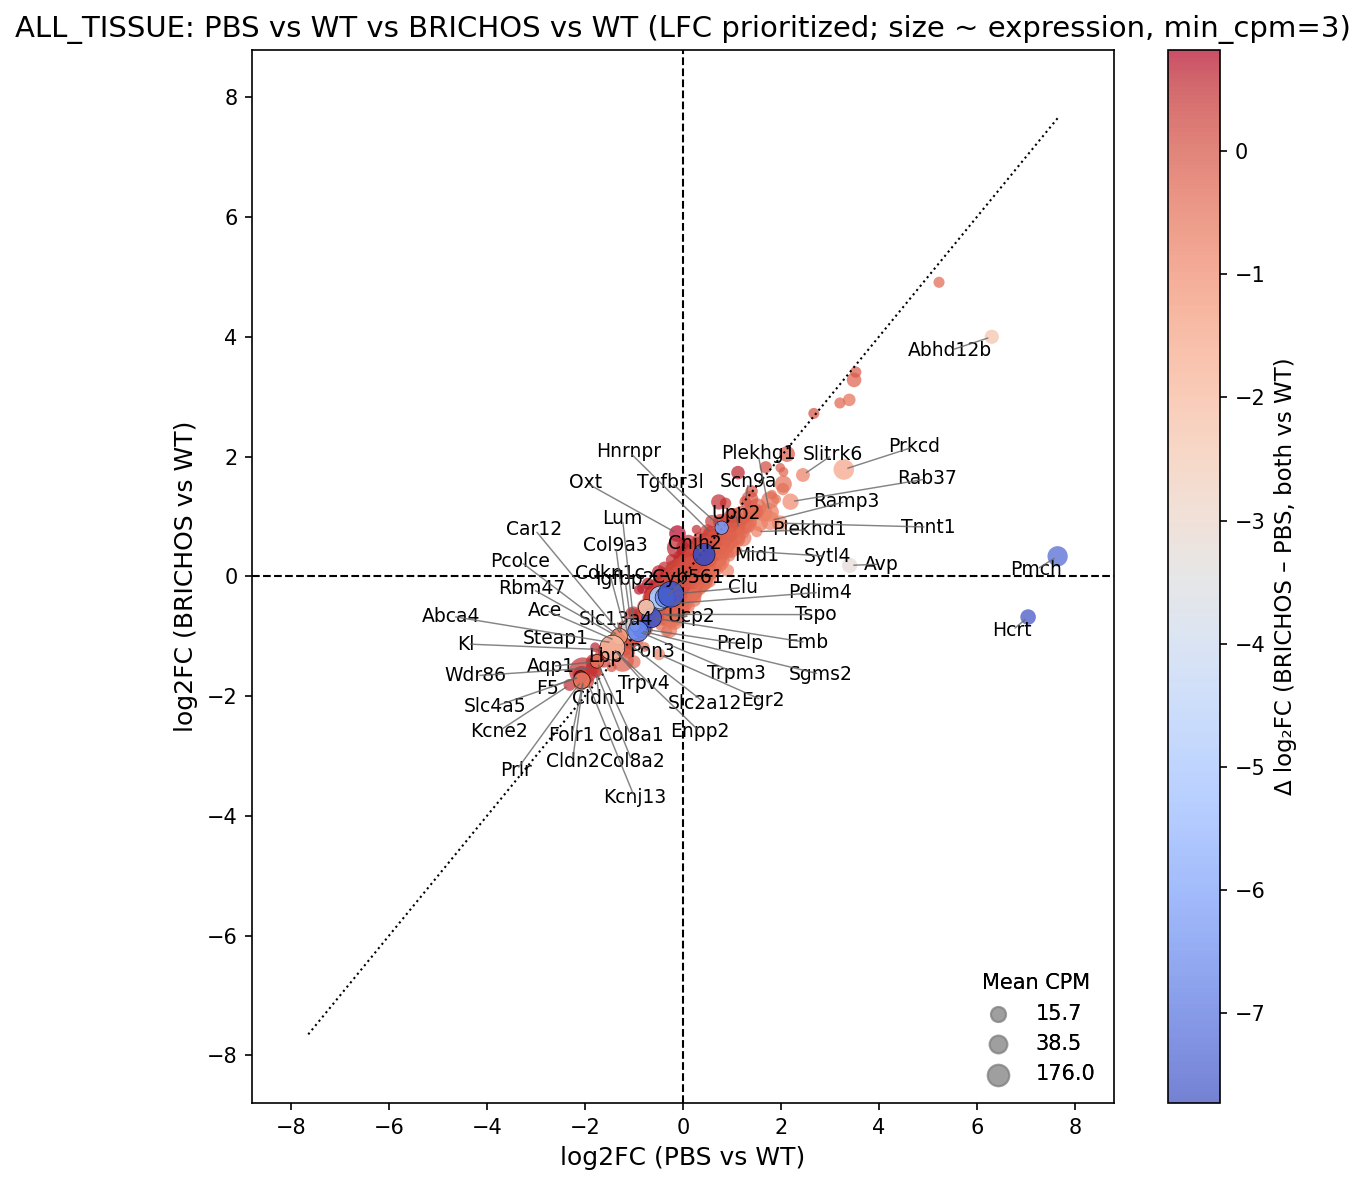

,baseMean,log2FC_PBS_vs_WT,lfcSE_PBS_vs_WT,stat,pvalue_PBS_vs_WT,padj_PBS_vs_WT,mean_cpm_all,detect_rate_all,mean_cpm_cond_BRICHOS,mean_cpm_cond_PBS,mean_cpm_cond_WT
Igfbp2,4132.319,-1.045,0.234,-4.472,0.000,0.011,108.675,1.0,107.050,95.477,192.734
Kcnj13,390.161,-1.954,0.594,-3.288,0.001,0.222,10.246,1.0,8.891,7.744,29.323
F5,327.383,-2.108,0.578,-3.649,0.000,0.114,8.596,1.0,8.135,6.026,25.396
Upp2,320.069,1.148,0.398,2.883,0.004,0.416,8.443,1.0,7.425,9.649,4.264
Scn9a,216.257,1.273,0.365,3.487,0.000,0.150,5.696,1.0,5.965,6.099,2.469
Lbp,418.333,-1.624,0.576,-2.818,0.005,0.457,10.998,1.0,10.217,8.802,26.518
Col9a3,1828.614,-1.133,0.352,-3.222,0.001,0.264,48.102,1.0,46.278,42.014,90.102
Abca4,265.665,-1.423,0.407,-3.499,0.000,0.146,6.985,1.0,7.016,5.659,14.849
Col8a2,278.468,-1.781,0.492,-3.619,0.000,0.117,7.315,1.0,6.569,5.709,19.187
Steap1,124.843,-1.794,0.570,-3.149,0.002,0.293,3.281,1.0,3.586,2.348,7.967


,baseMean,log2FC_BRICHOS_vs_WT,lfcSE_BRICHOS_vs_WT,stat,pvalue_BRICHOS_vs_WT,padj_BRICHOS_vs_WT,mean_cpm_all,detect_rate_all,mean_cpm_cond_BRICHOS,mean_cpm_cond_PBS,mean_cpm_cond_WT
Prelp,778.470,-0.878,0.141,-6.235,0.0,0.000,20.464,1.0,18.552,19.263,33.400
Sgms2,247.916,-0.907,0.209,-4.339,0.0,0.046,6.515,1.0,5.948,6.064,10.921
Hnrnpr,779.819,0.709,0.192,3.690,0.0,0.350,20.549,1.0,22.442,20.783,13.465
Pon3,381.326,-1.102,0.303,-3.635,0.0,0.402,10.027,1.0,8.915,9.132,18.739
Ucp2,1544.608,-0.645,0.174,-3.710,0.0,0.350,40.624,1.0,35.205,41.109,53.971
Tgfbr3l,288.670,0.812,0.195,4.154,0.0,0.088,7.605,1.0,8.040,7.907,4.488
Lum,120.397,-0.836,0.232,-3.612,0.0,0.407,3.163,1.0,3.122,2.801,5.461
Pdlim4,574.488,-0.462,0.123,-3.748,0.0,0.335,15.114,1.0,13.817,15.171,18.664
Cyb561,2494.798,-0.354,0.069,-5.122,0.0,0.002,65.618,1.0,64.208,63.856,80.415
Emb,2157.769,-0.693,0.129,-5.355,0.0,0.001,56.732,1.0,52.416,54.506,83.033


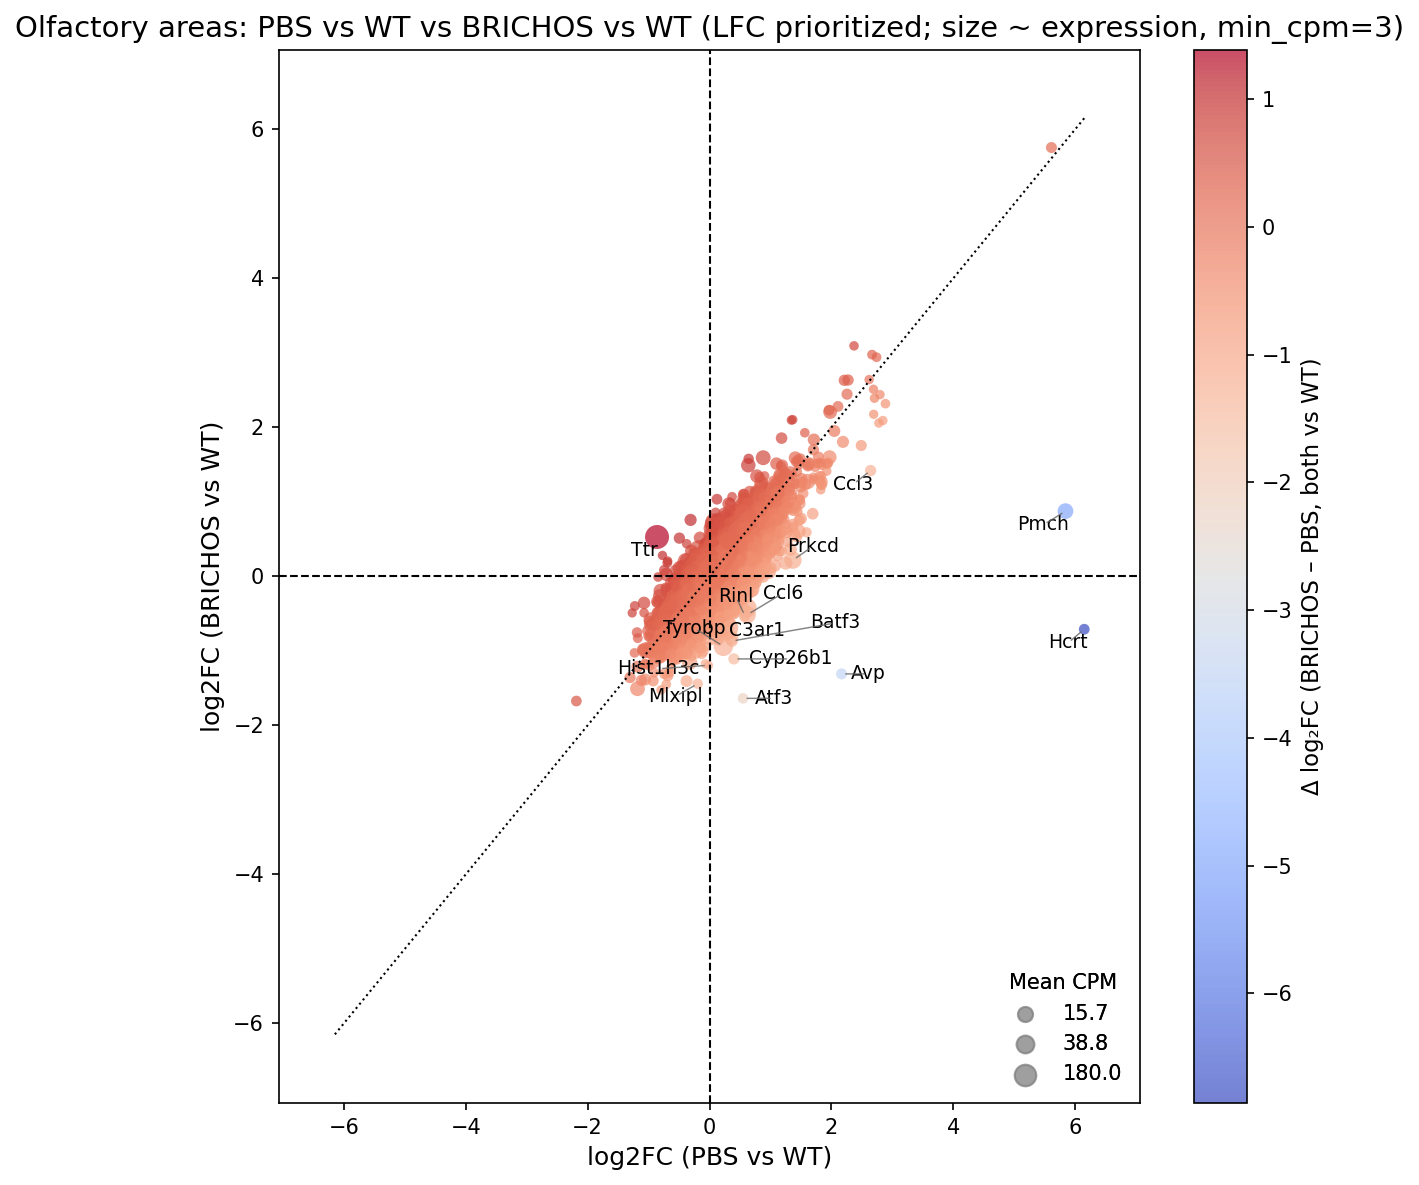

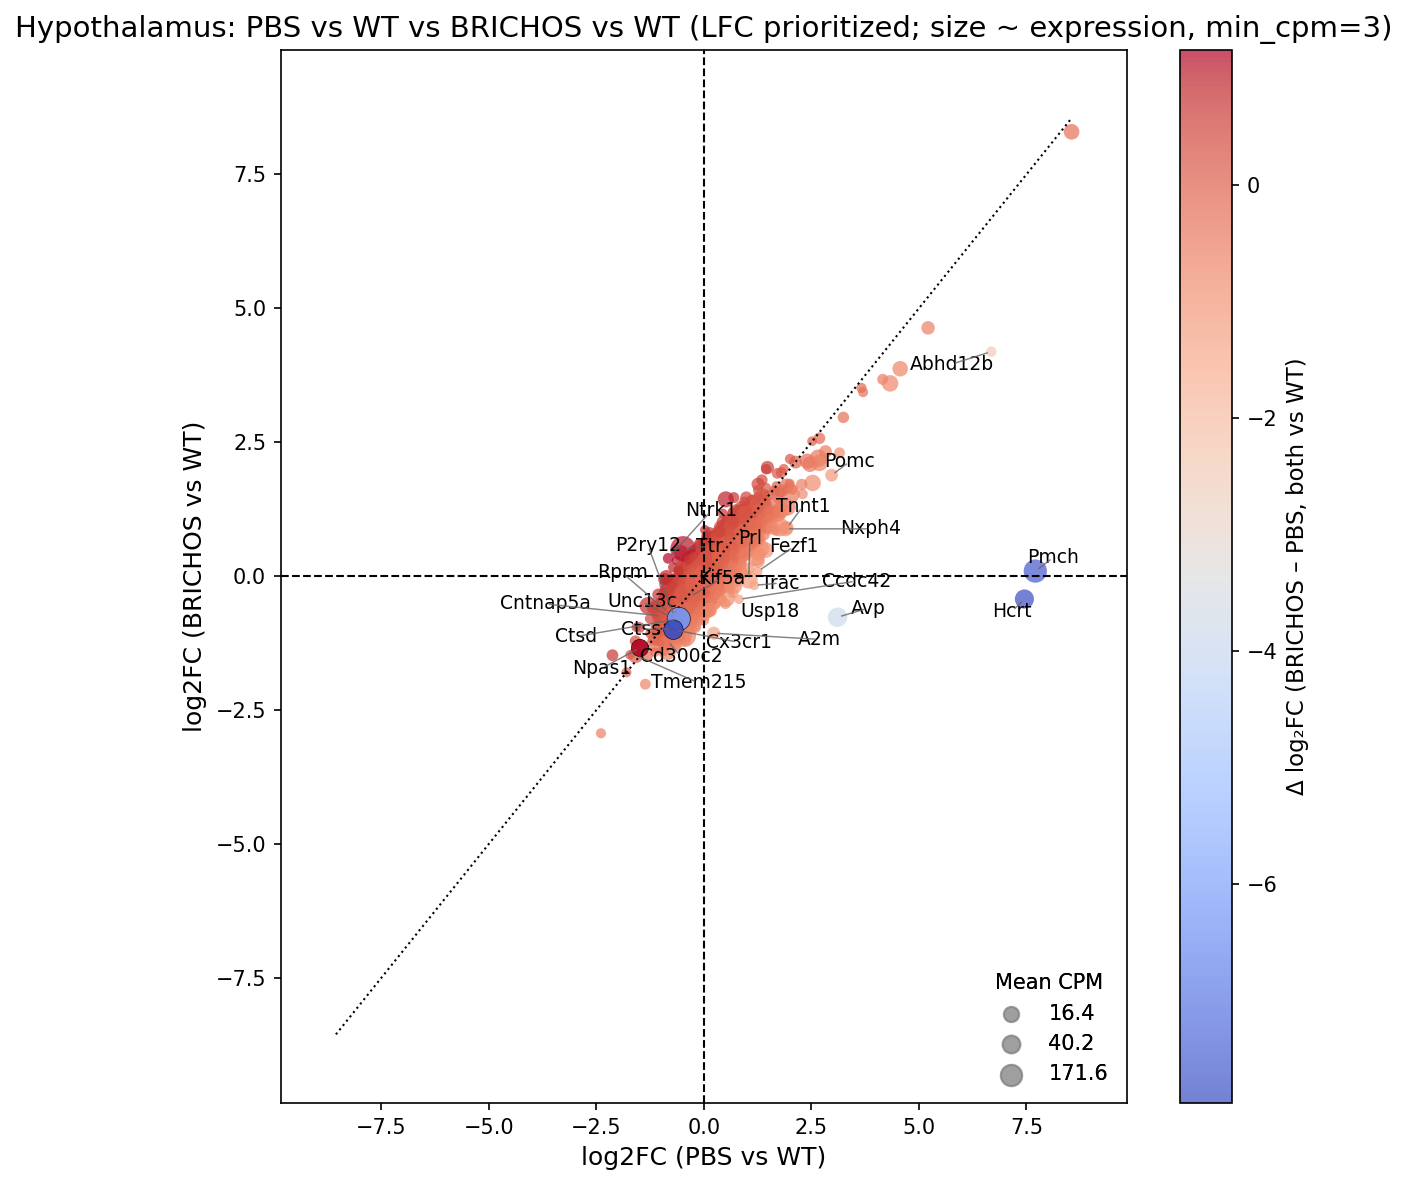

,baseMean,log2FC_PBS_vs_WT,lfcSE_PBS_vs_WT,stat,pvalue_PBS_vs_WT,padj_PBS_vs_WT,mean_cpm_all,detect_rate_all,mean_cpm_cond_BRICHOS,mean_cpm_cond_PBS,mean_cpm_cond_WT
Cntnap5a,268.010,-0.970,0.254,-3.825,0.0,0.430,57.771,1.0,58.414,50.910,97.002
Rprm,122.378,-0.823,0.220,-3.738,0.0,0.471,26.381,1.0,26.476,23.802,41.572
P2ry12,347.581,-0.684,0.170,-4.020,0.0,0.258,74.965,1.0,69.095,71.532,113.169
Tmem215,86.701,-1.581,0.387,-4.088,0.0,0.257,18.690,1.0,16.739,15.248,45.202
Npas1,114.594,-1.483,0.286,-5.181,0.0,0.004,24.680,1.0,22.199,20.687,56.090
Ctsd,1236.995,-0.582,0.131,-4.443,0.0,0.079,266.866,1.0,228.932,265.368,389.659
Unc13c,877.802,-0.751,0.198,-3.799,0.0,0.430,189.391,1.0,175.252,179.029,293.976


,baseMean,log2FC_BRICHOS_vs_WT,lfcSE_BRICHOS_vs_WT,stat,pvalue_BRICHOS_vs_WT,padj_BRICHOS_vs_WT,mean_cpm_all,detect_rate_all,mean_cpm_cond_BRICHOS,mean_cpm_cond_PBS,mean_cpm_cond_WT
P2ry12,347.581,-0.751,0.182,-4.122,0.0,0.139,74.965,1.0,69.095,71.532,113.169
Ctss,862.718,-0.986,0.240,-4.112,0.0,0.139,186.158,1.0,153.296,184.124,296.946
Npas1,114.594,-1.337,0.307,-4.351,0.0,0.080,24.680,1.0,22.199,20.687,56.090
Ctsd,1236.995,-0.797,0.140,-5.685,0.0,0.000,266.866,1.0,228.932,265.368,389.659
Cx3cr1,254.228,-0.997,0.211,-4.726,0.0,0.020,54.853,1.0,44.754,54.583,86.774
Kif5a,2882.362,-0.384,0.099,-3.881,0.0,0.305,621.896,1.0,590.136,615.003,758.531
Cd300c2,83.356,-1.199,0.312,-3.845,0.0,0.305,17.995,1.0,14.066,17.789,31.014


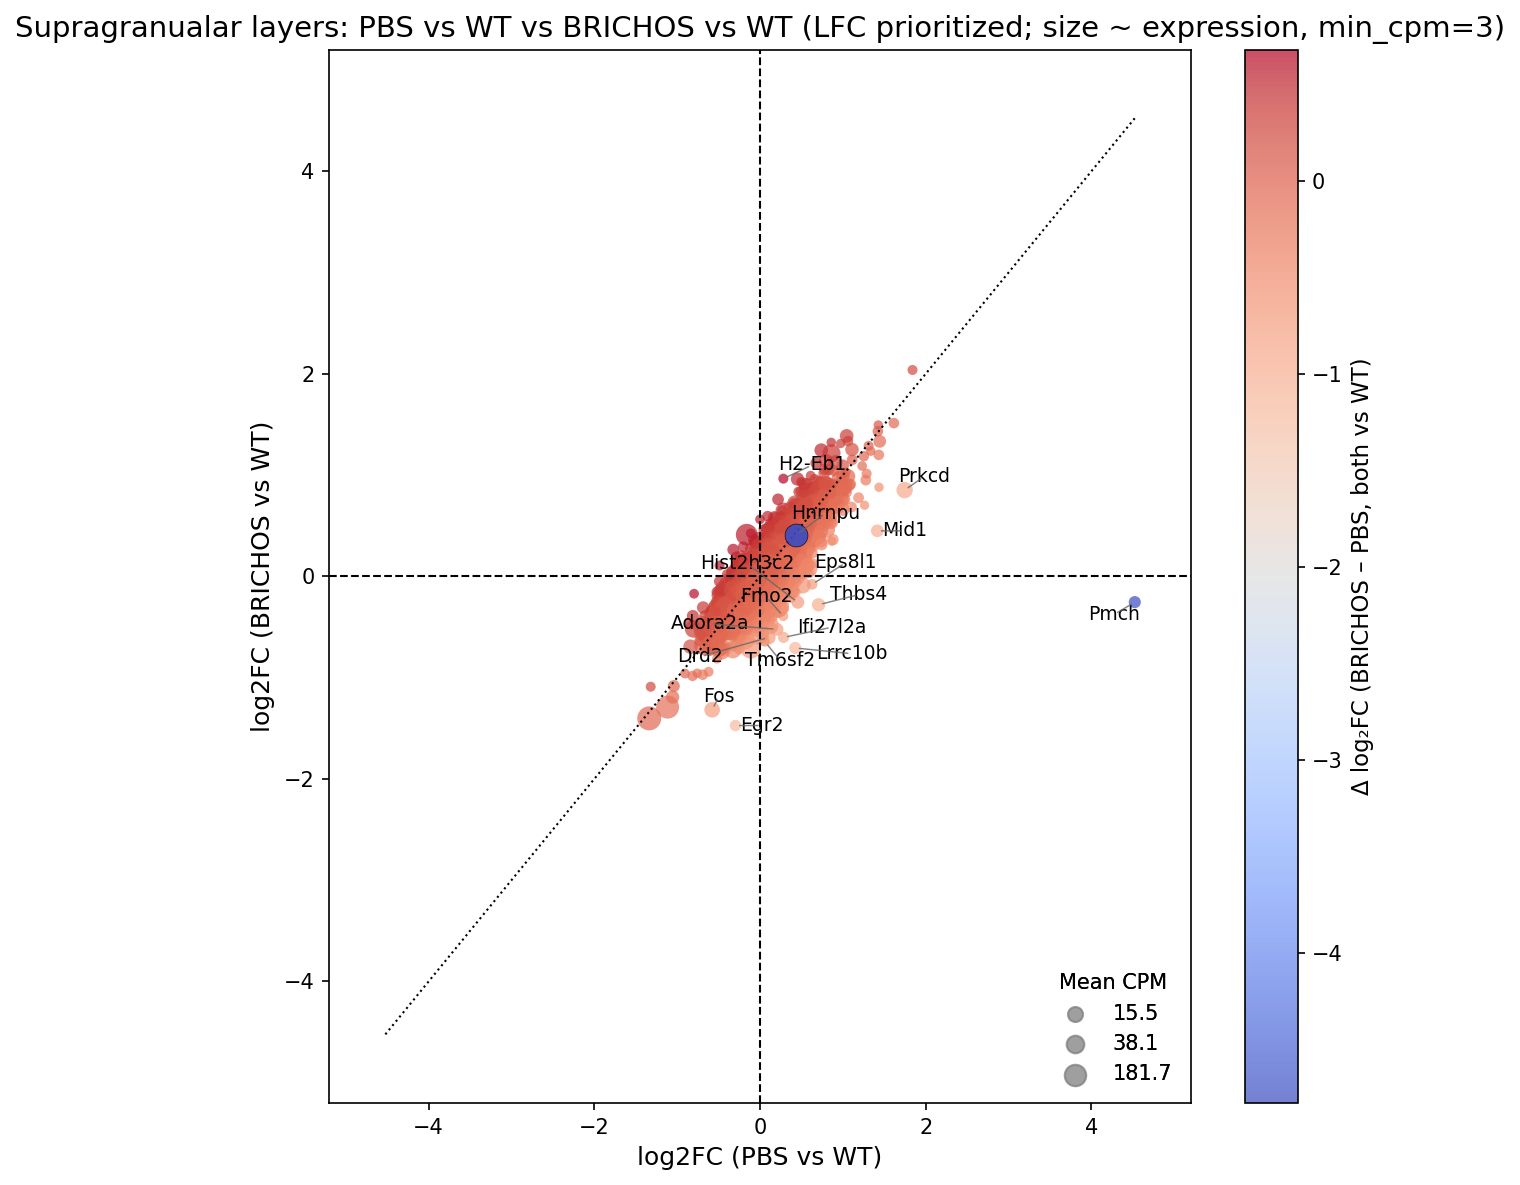

,baseMean,log2FC_PBS_vs_WT,lfcSE_PBS_vs_WT,stat,pvalue_PBS_vs_WT,padj_PBS_vs_WT,mean_cpm_all,detect_rate_all,mean_cpm_cond_BRICHOS,mean_cpm_cond_PBS,mean_cpm_cond_WT
Hnrnpu,1789.331,0.439,0.092,4.778,0.0,0.032,225.401,1.0,228.414,233.521,167.638


,baseMean,log2FC_BRICHOS_vs_WT,lfcSE_BRICHOS_vs_WT,stat,pvalue_BRICHOS_vs_WT,padj_BRICHOS_vs_WT,mean_cpm_all,detect_rate_all,mean_cpm_cond_BRICHOS,mean_cpm_cond_PBS,mean_cpm_cond_WT
Hnrnpu,1789.331,0.41,0.098,4.198,0.0,0.481,225.401,1.0,228.414,233.521,167.638


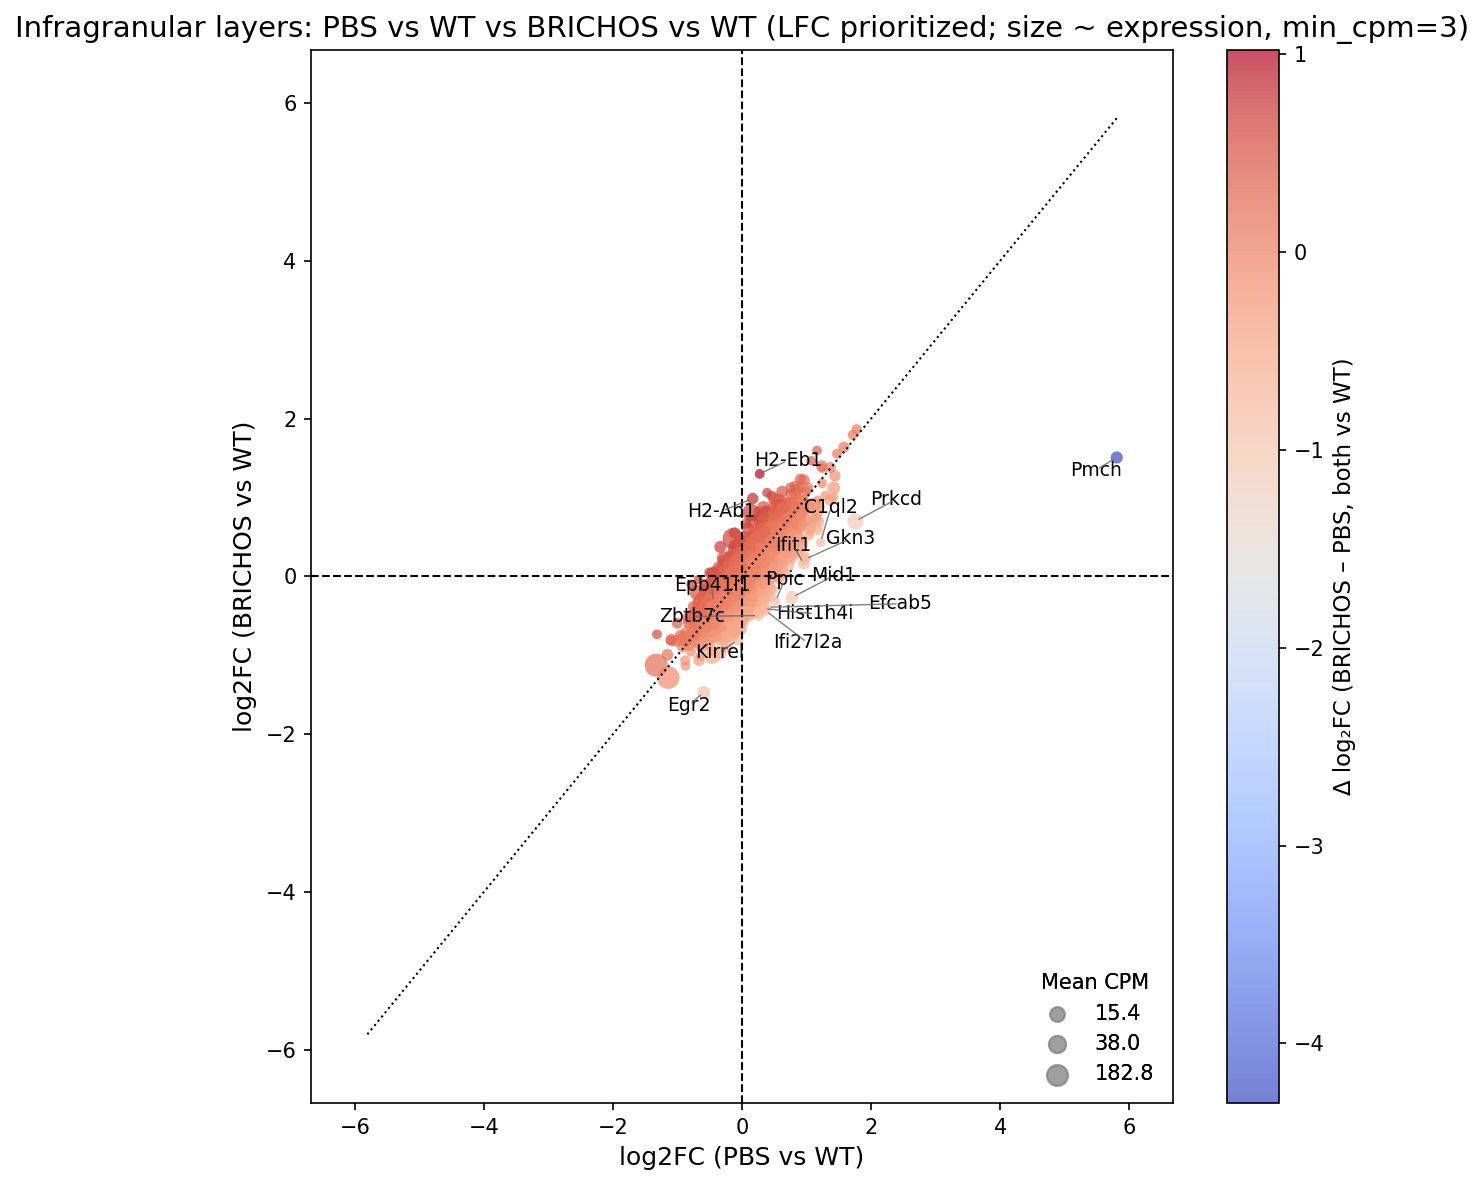

,baseMean,log2FC_PBS_vs_WT,lfcSE_PBS_vs_WT,stat,pvalue_PBS_vs_WT,padj_PBS_vs_WT,mean_cpm_all,detect_rate_all,mean_cpm_cond_BRICHOS,mean_cpm_cond_PBS,mean_cpm_cond_WT
Epb41l1,2797.599,-0.449,0.104,-4.327,0.0,0.132,550.425,1.0,561.858,520.824,693.735


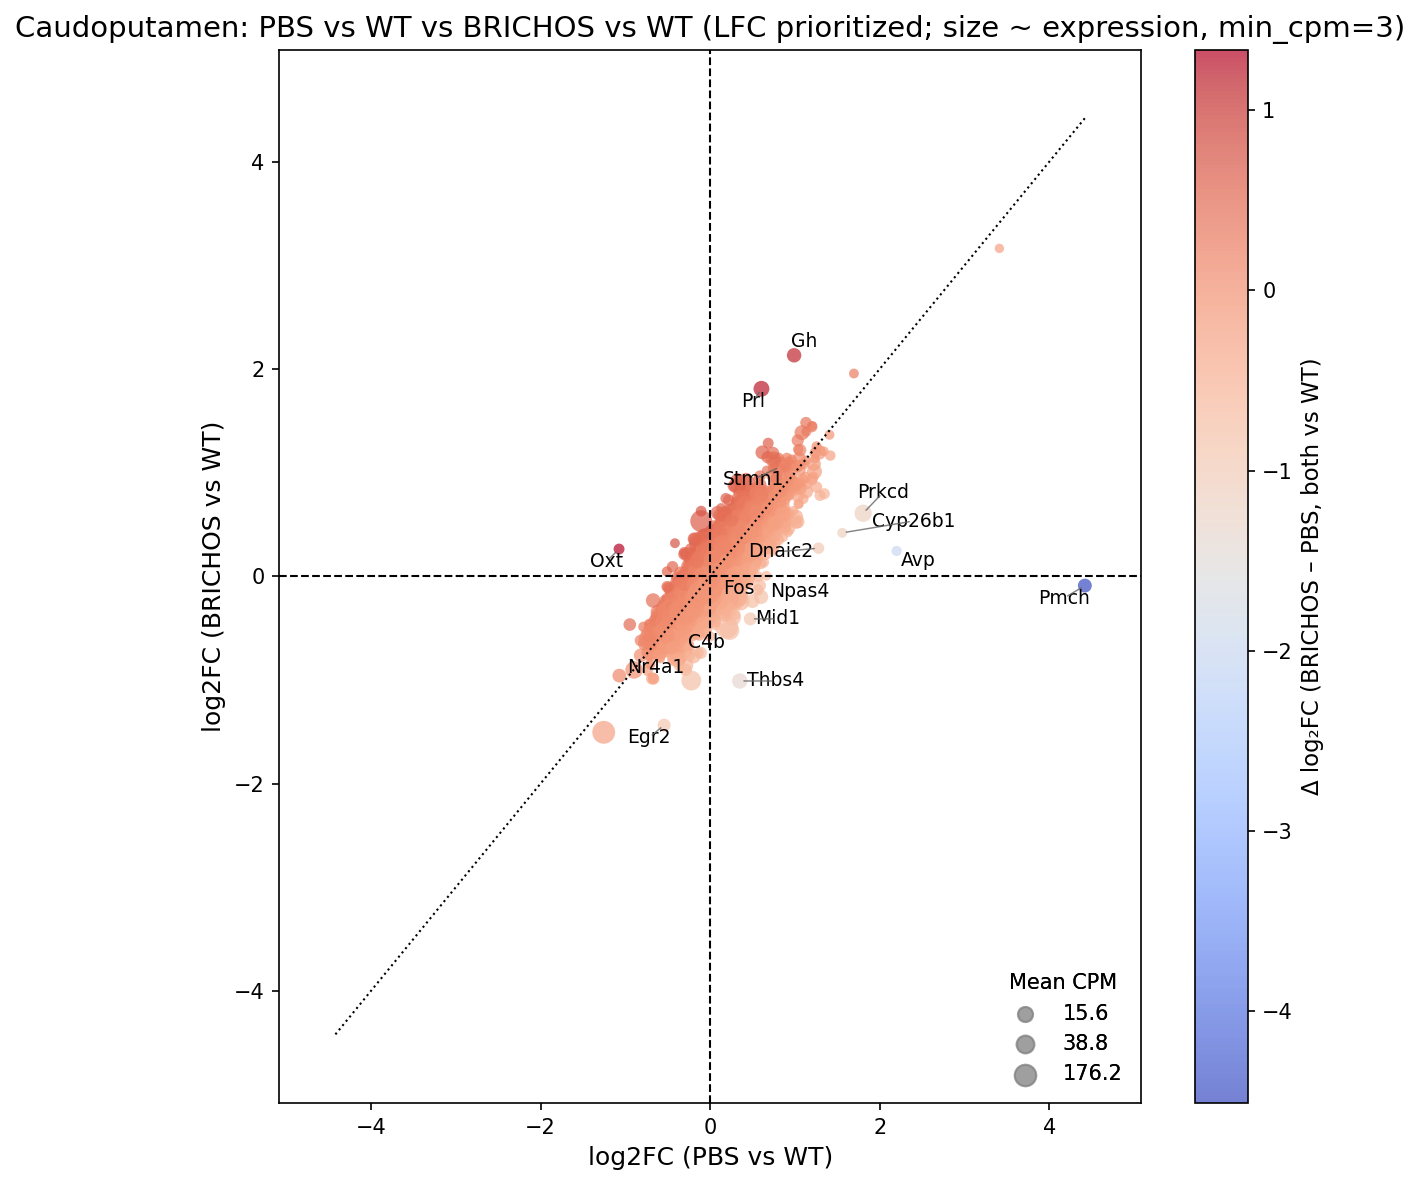

,baseMean,log2FC_BRICHOS_vs_WT,lfcSE_BRICHOS_vs_WT,stat,pvalue_BRICHOS_vs_WT,padj_BRICHOS_vs_WT,mean_cpm_all,detect_rate_all,mean_cpm_cond_BRICHOS,mean_cpm_cond_PBS,mean_cpm_cond_WT
Stmn1,689.567,1.058,0.235,4.501,0.0,0.123,99.061,1.0,115.288,98.498,53.759


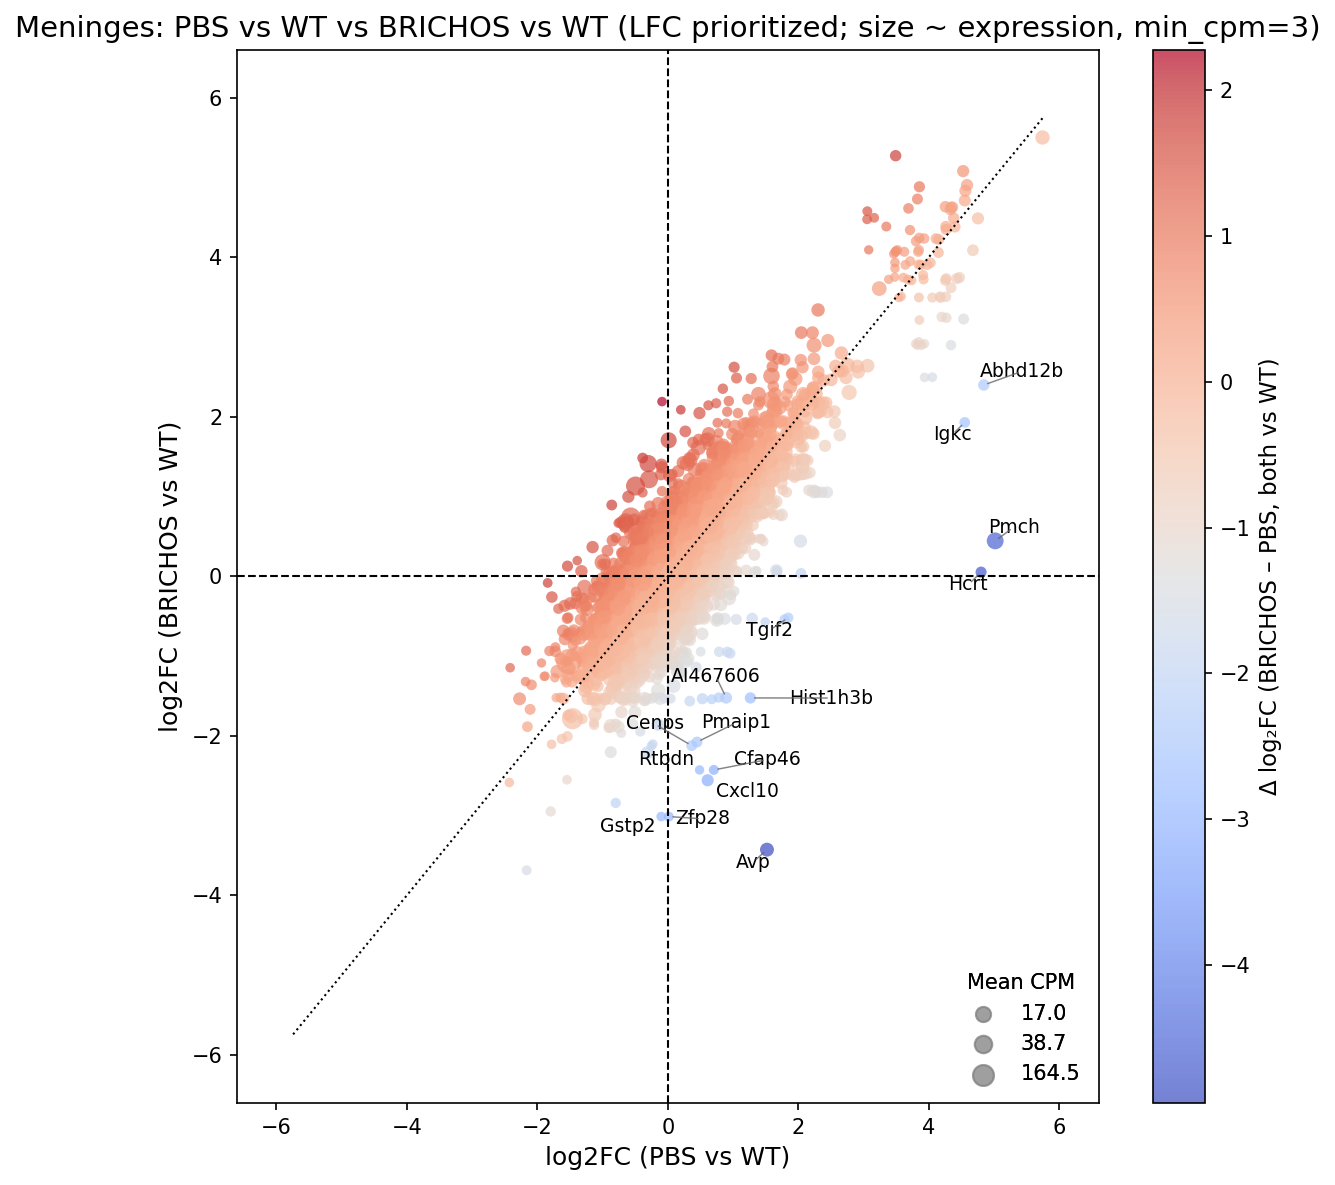

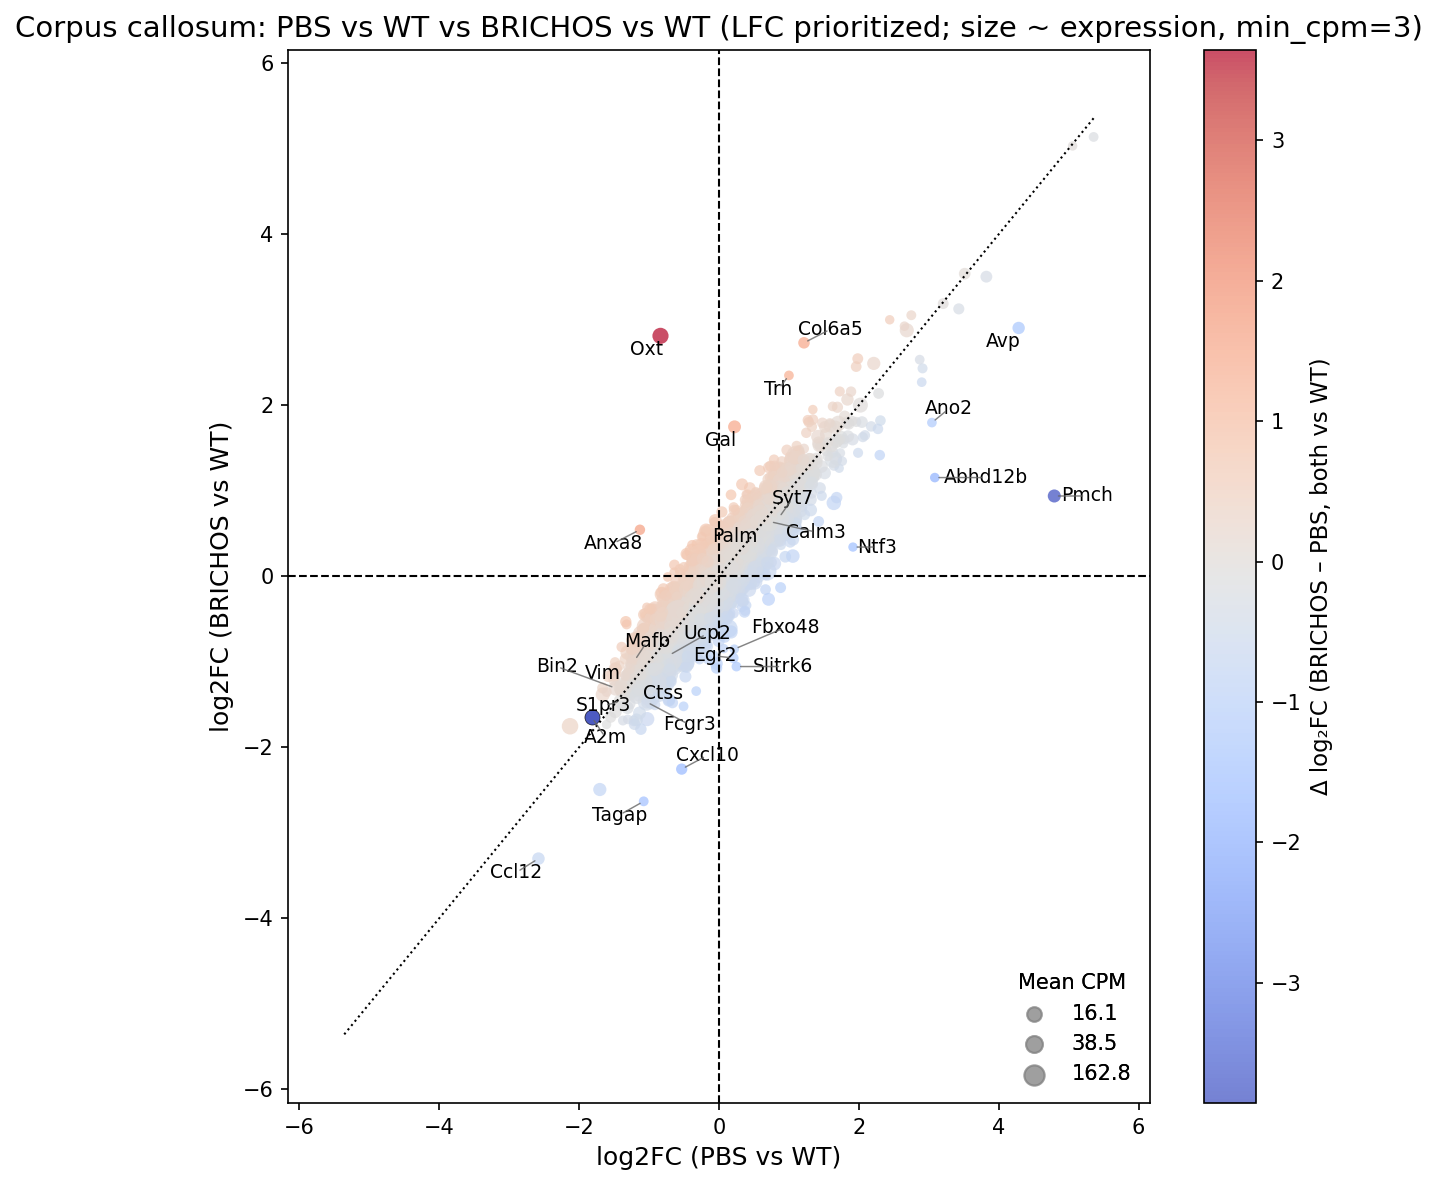

,baseMean,log2FC_PBS_vs_WT,lfcSE_PBS_vs_WT,stat,pvalue_PBS_vs_WT,padj_PBS_vs_WT,mean_cpm_all,detect_rate_all,mean_cpm_cond_BRICHOS,mean_cpm_cond_PBS,mean_cpm_cond_WT
Vim,297.874,-1.365,0.314,-4.354,0.0,0.058,128.036,1.0,114.950,109.733,277.115
Mafb,45.654,-1.209,0.314,-3.851,0.0,0.233,19.644,1.0,19.694,16.582,37.863
A2m,35.125,-1.820,0.407,-4.468,0.0,0.046,15.076,1.0,12.845,11.936,40.607
Calm3,655.573,0.722,0.189,3.819,0.0,0.233,282.605,1.0,284.036,299.357,177.793
Ccl12,18.885,-2.581,0.671,-3.845,0.0,0.233,8.072,1.0,3.738,5.823,34.571
S1pr3,42.069,-1.399,0.340,-4.119,0.0,0.133,18.088,1.0,15.653,15.552,40.607
Bin2,42.616,-1.475,0.363,-4.065,0.0,0.139,18.270,1.0,16.873,15.245,40.607
Syt7,478.435,0.854,0.216,3.959,0.0,0.187,206.191,1.0,198.821,224.029,121.272


,baseMean,log2FC_BRICHOS_vs_WT,lfcSE_BRICHOS_vs_WT,stat,pvalue_BRICHOS_vs_WT,padj_BRICHOS_vs_WT,mean_cpm_all,detect_rate_all,mean_cpm_cond_BRICHOS,mean_cpm_cond_PBS,mean_cpm_cond_WT
Fcgr3,126.545,-1.469,0.362,-4.057,0.0,0.281,54.281,1.0,38.378,53.536,106.456
Vim,297.874,-1.300,0.336,-3.874,0.0,0.313,128.036,1.0,114.950,109.733,277.115
Ctss,624.004,-1.223,0.336,-3.637,0.0,0.480,267.402,1.0,225.127,247.594,513.074
A2m,35.125,-1.647,0.436,-3.776,0.0,0.396,15.076,1.0,12.845,11.936,40.607
Ucp2,130.369,-0.926,0.239,-3.872,0.0,0.313,56.089,1.0,47.528,54.993,88.348
Palm,450.083,0.632,0.173,3.660,0.0,0.480,194.064,1.0,207.043,198.152,130.601
Ccl12,18.885,-3.302,0.743,-4.445,0.0,0.153,8.072,1.0,3.738,5.823,34.571
S1pr3,42.069,-1.461,0.366,-3.995,0.0,0.281,18.088,1.0,15.653,15.552,40.607


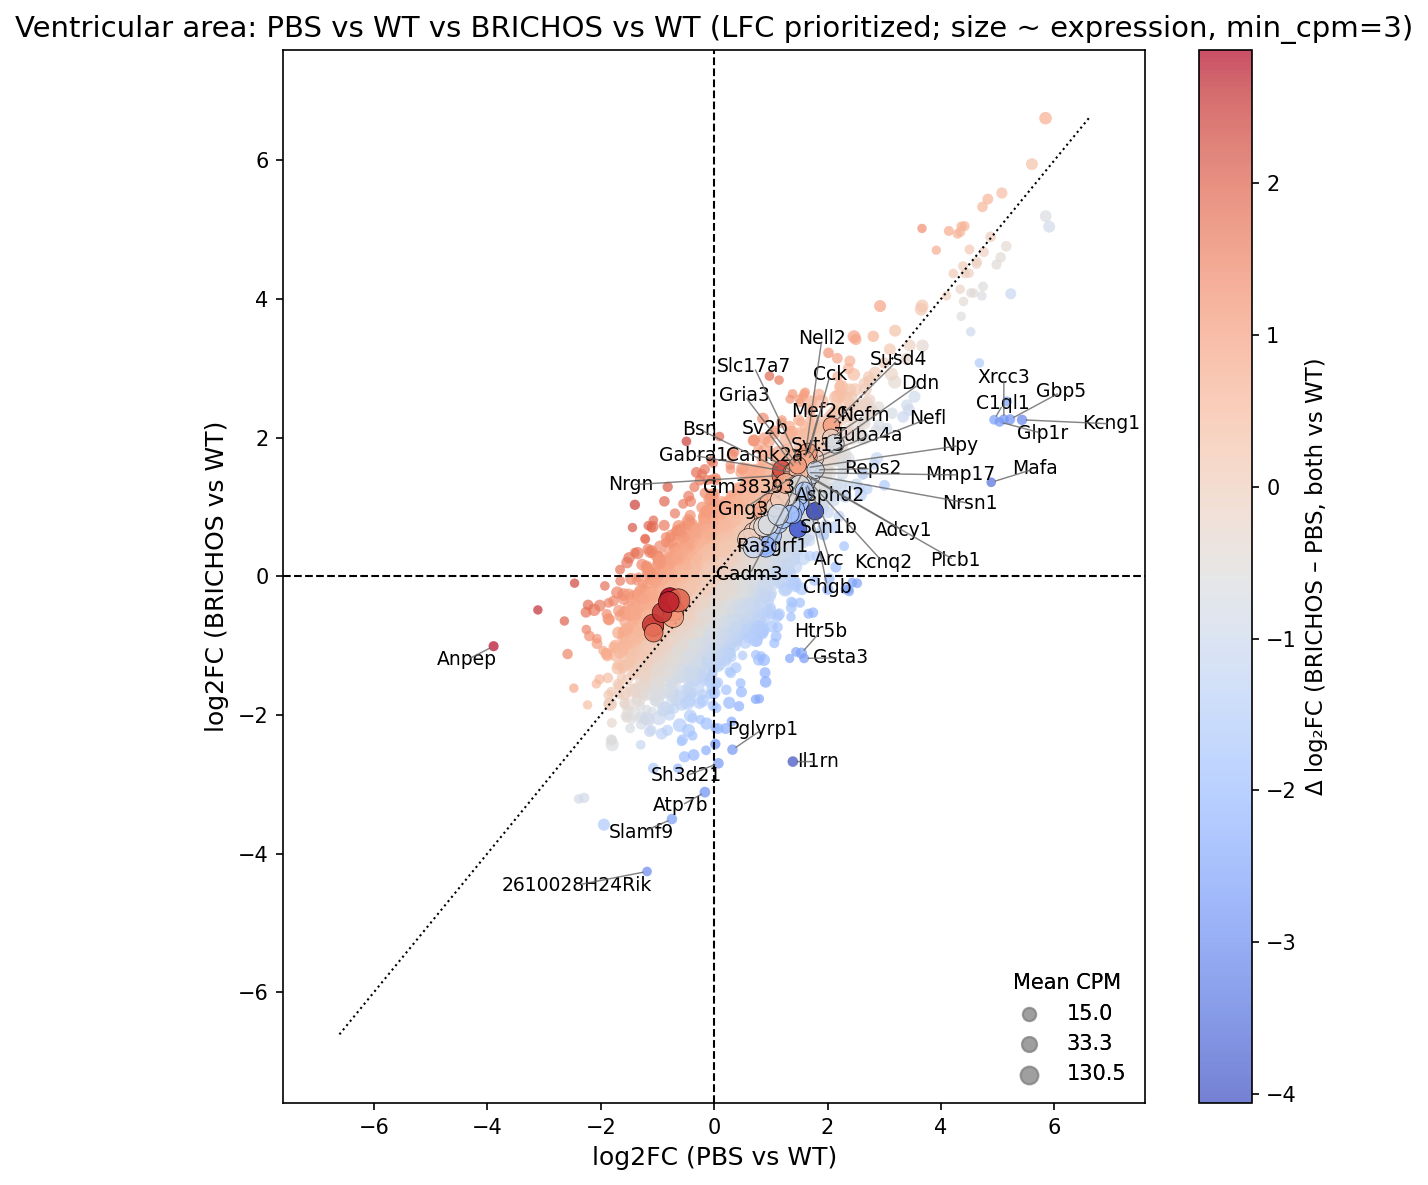

,baseMean,log2FC_PBS_vs_WT,lfcSE_PBS_vs_WT,stat,pvalue_PBS_vs_WT,padj_PBS_vs_WT,mean_cpm_all,detect_rate_all,mean_cpm_cond_BRICHOS,mean_cpm_cond_PBS,mean_cpm_cond_WT
Tuba4a,22.423,1.785,0.509,3.506,0.000,0.024,57.334,1.0,57.256,64.046,17.297
Susd4,20.053,2.068,0.576,3.590,0.000,0.018,51.156,1.0,56.272,55.152,11.835
Syt13,30.269,1.639,0.464,3.535,0.000,0.022,77.129,1.0,79.557,84.672,24.580
Chgb,42.872,1.605,0.396,4.057,0.000,0.005,109.764,1.0,96.580,128.429,37.326
Plcb1,34.974,1.654,0.400,4.136,0.000,0.004,89.557,1.0,81.994,103.409,29.132
Kcnq2,42.059,1.645,0.417,3.945,0.000,0.007,107.988,1.0,95.395,126.214,36.415
Asphd2,19.566,1.798,0.581,3.096,0.002,0.063,50.553,1.0,38.684,62.334,15.477
Mmp17,21.901,1.623,0.487,3.334,0.001,0.036,56.230,1.0,52.881,64.089,19.118
Npy,21.619,1.617,0.503,3.216,0.001,0.047,55.197,1.0,54.879,61.521,18.208
Scn1b,93.147,1.610,0.348,4.629,0.000,0.001,239.134,1.0,213.697,277.900,82.845


,baseMean,log2FC_BRICHOS_vs_WT,lfcSE_BRICHOS_vs_WT,stat,pvalue_BRICHOS_vs_WT,padj_BRICHOS_vs_WT,mean_cpm_all,detect_rate_all,mean_cpm_cond_BRICHOS,mean_cpm_cond_PBS,mean_cpm_cond_WT
Cadm3,42.895,1.527,0.397,3.846,0.000,0.015,109.429,1.0,107.369,122.628,36.415
Syt13,30.269,1.662,0.492,3.378,0.001,0.049,77.129,1.0,79.557,84.672,24.580
Slc17a7,154.649,1.557,0.373,4.173,0.000,0.006,394.466,1.0,405.149,432.413,134.737
Gm38393,26.245,1.467,0.462,3.175,0.001,0.081,66.785,1.0,71.249,71.587,24.580
Sv2b,28.631,1.546,0.505,3.063,0.002,0.105,72.935,1.0,77.671,78.323,26.401
Nrgn,103.142,1.455,0.340,4.279,0.000,0.005,261.751,1.0,300.867,268.066,106.515
Bsn,47.217,1.538,0.368,4.179,0.000,0.006,119.870,1.0,141.483,120.999,48.251
Cck,68.711,1.715,0.374,4.590,0.000,0.002,174.597,1.0,184.024,189.878,54.623
Adcy1,30.344,1.463,0.472,3.100,0.002,0.096,77.406,1.0,71.747,88.736,26.401
Gabra1,61.940,1.497,0.390,3.837,0.000,0.015,157.768,1.0,168.001,169.235,58.265


7 [0.37783019 0.43844654]
12 [0.96103956 0.85957823]
4 [0.8363931  0.64361812]
6 [-0.94890834 -0.95053861]
11 [-0.96549322 -0.22037008]


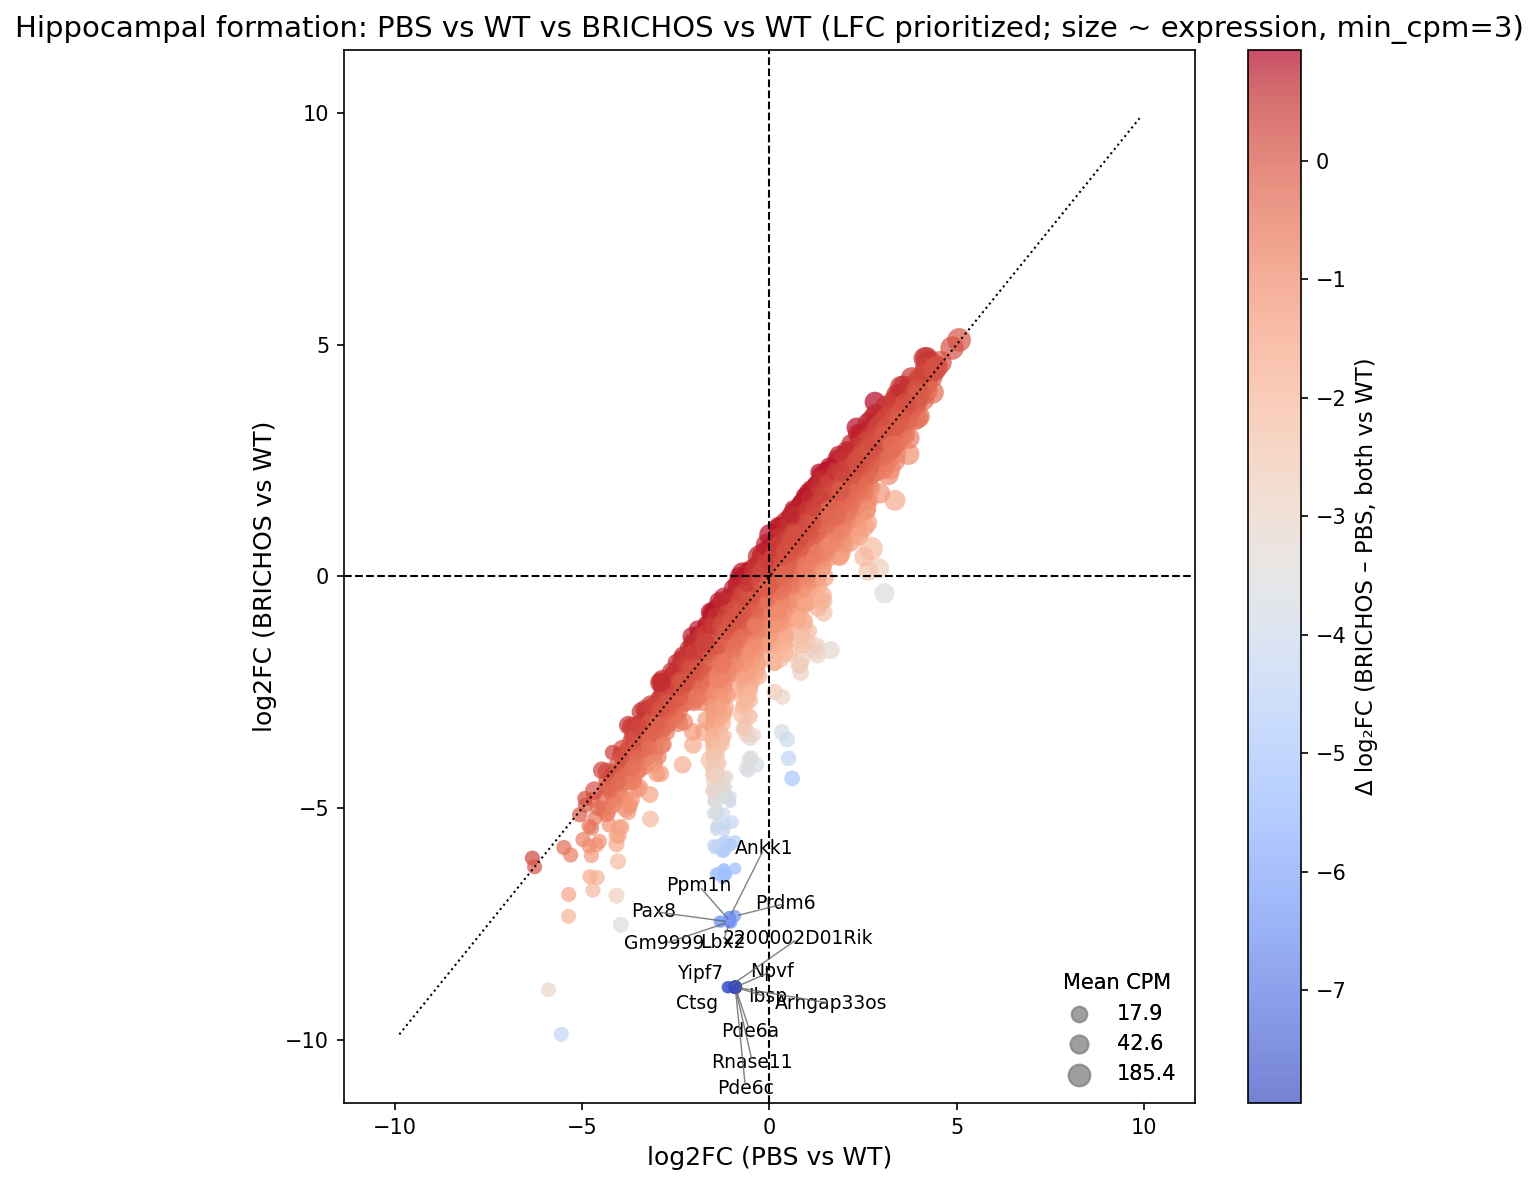

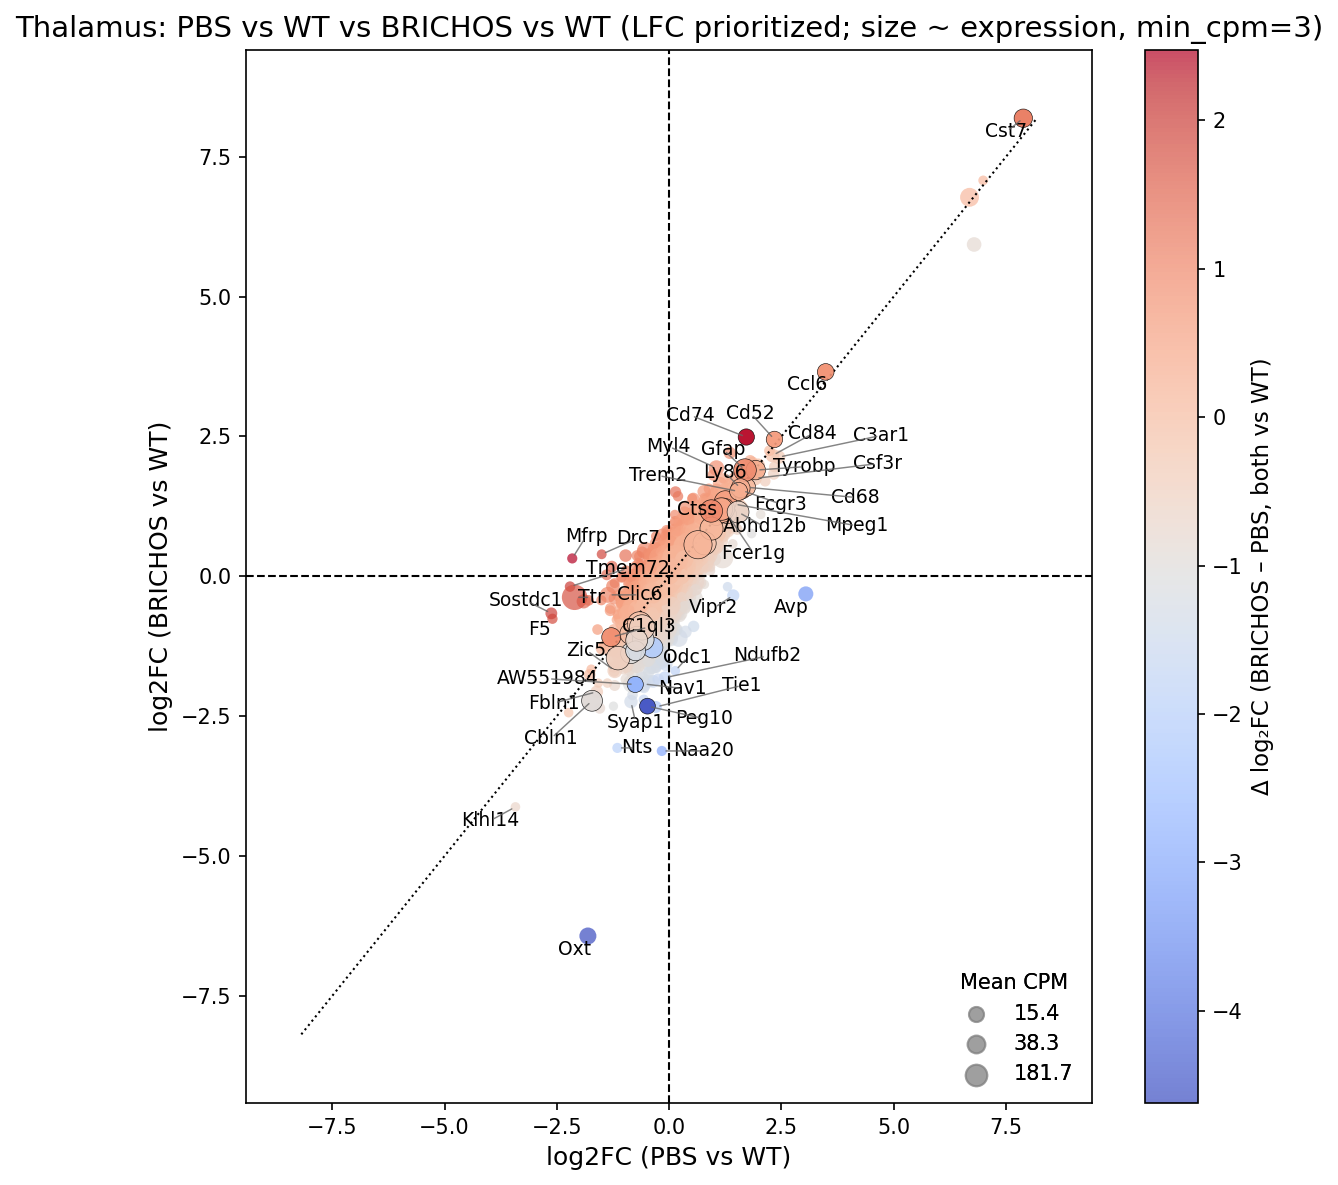

,baseMean,log2FC_PBS_vs_WT,lfcSE_PBS_vs_WT,stat,pvalue_PBS_vs_WT,padj_PBS_vs_WT,mean_cpm_all,detect_rate_all,mean_cpm_cond_BRICHOS,mean_cpm_cond_PBS,mean_cpm_cond_WT
Fcgr3,176.298,1.618,0.395,4.096,0.000,0.023,25.761,1.0,30.025,31.339,10.339
Fcer1g,259.355,1.296,0.331,3.918,0.000,0.045,37.904,1.0,40.826,45.917,18.954
Cd84,69.492,2.301,0.659,3.490,0.000,0.161,10.162,1.0,11.990,12.988,2.680
C1ql3,312.601,-1.288,0.290,-4.437,0.000,0.006,45.821,1.0,37.854,32.508,80.412
Cst7,248.236,7.884,1.478,5.334,0.000,0.000,36.301,1.0,55.889,44.563,0.191
Ctss,1007.095,1.252,0.215,5.823,0.000,0.000,147.208,1.0,180.449,168.390,71.605
Csf3r,84.790,1.905,0.559,3.406,0.001,0.208,12.385,1.0,14.170,15.579,4.212
Cd52,129.693,2.345,0.489,4.793,0.000,0.001,18.947,1.0,25.071,23.061,4.595
C3ar1,68.276,2.435,0.657,3.707,0.000,0.083,9.975,1.0,10.900,13.256,2.489
Tyrobp,365.067,1.928,0.303,6.358,0.000,0.000,53.338,1.0,65.005,65.462,17.423


,baseMean,log2FC_BRICHOS_vs_WT,lfcSE_BRICHOS_vs_WT,stat,pvalue_BRICHOS_vs_WT,padj_BRICHOS_vs_WT,mean_cpm_all,detect_rate_all,mean_cpm_cond_BRICHOS,mean_cpm_cond_PBS,mean_cpm_cond_WT
Nav1,128.200,-1.924,0.525,-3.661,0.000,0.091,18.732,1.0,7.630,19.194,28.910
Cd84,69.492,2.160,0.728,2.965,0.003,0.376,10.162,1.0,11.990,12.988,2.680
Cst7,248.236,8.188,1.489,5.497,0.000,0.000,36.301,1.0,55.889,44.563,0.191
Csf3r,84.790,1.749,0.621,2.814,0.005,0.478,12.385,1.0,14.170,15.579,4.212
Cd52,129.693,2.446,0.537,4.551,0.000,0.006,18.947,1.0,25.071,23.061,4.595
Peg10,106.468,-2.321,0.570,-4.071,0.000,0.026,15.550,1.0,4.756,16.852,23.741
C3ar1,68.276,2.129,0.724,2.941,0.003,0.384,9.975,1.0,10.900,13.256,2.489
Tyrobp,365.067,1.898,0.339,5.601,0.000,0.000,53.338,1.0,65.005,65.462,17.423
Cbln1,615.285,-2.225,0.294,-7.577,0.000,0.000,90.171,1.0,42.511,59.817,198.541
AW551984,119.330,-1.933,0.498,-3.877,0.000,0.046,17.463,1.0,7.531,16.800,28.719


In [33]:
# --- replicate your style for regional PBS/BRICHOS vs WT comparisons ---

from IPython.display import display, HTML
import pandas as pd
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text

# --- Keep vector text editable for Illustrator ---
mpl.rcParams['svg.fonttype'] = 'none'   # text stays as text
mpl.rcParams['pdf.fonttype'] = 42       # embed fonts in PDF
mpl.rcParams['text.usetex'] = False

# --- Output directory ---
outdir = "../results/figures"
os.makedirs(outdir, exist_ok=True)

# -------------------------
# helpers (mirroring yours)
# -------------------------
def _display_top_table(res, top, region, tag, head=20):
    """Display a nicely formatted subset of DE results."""
    if res is None or not isinstance(res, pd.DataFrame) or len(top) == 0:
        display(HTML(f"<h4 style='color:gray;margin:0.6em 0;'>⚠️ {region} — {tag}: no data</h4>"))
        return
    idx = res.index.intersection(pd.Index(top))
    if len(idx) == 0:
        display(HTML(f"<h4 style='color:gray;margin:0.6em 0;'>⚠️ {region} — {tag}: none of the requested genes found</h4>"))
        return

    sub = res.loc[idx].copy()
    num_cols = sub.select_dtypes(include="number").columns
    sub[num_cols] = sub[num_cols].round(3)

    display(HTML(f"<h3 style='color:#2a4d69;margin:0.6em 0 0.2em 0;'>{region} — Top {len(idx)} genes for {tag}</h3>"))
    display(sub.head(head))


from IPython.display import display, HTML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

def compare_lfc_scatter_colored_labels_regions(
    res_x, res_y,
    lfc_col_x="log2FC_PBS_vs_WT",
    padj_col_x="padj_PBS_vs_WT",
    lfc_col_y="log2FC_BRICHOS_vs_WT",
    padj_col_y="padj_BRICHOS_vs_WT",
    title=None,
    highlight_genes=None,
    expr=None,
    size_min=20, size_max=180,
    use_log_expr=True,
    q=0.05,
    figsize=(8, 8),
    fontsize=12,
    top_n_delta=15,
    save_base=None,
    save_formats=("png", "svg", "pdf"),
    dpi=300,
    fixed_lim=None,      # <- set e.g. 3.0 for ±3; None = use full max range from data
    pad_frac=0.15        # small padding around limits
):
    """
    LFC scatter (PBS_vs_WT on x, BRICHOS_vs_WT on y) with ΔLFC = y - x colored.
    NO ZOOM: axes cover full symmetric range (or fixed_lim if provided).
    """
    # merge inputs
    genes = res_x.index.intersection(res_y.index)
    df = (
        res_x.loc[genes, [lfc_col_x, padj_col_x]]
        .rename(columns={lfc_col_x: "lfc_x", padj_col_x: "padj_x"})
        .join(
            res_y.loc[genes, [lfc_col_y, padj_col_y]]
            .rename(columns={lfc_col_y: "lfc_y", padj_col_y: "padj_y"})
        )
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["lfc_x", "lfc_y"])
    )

    df["deltaLFC"] = df["lfc_y"] - df["lfc_x"]
    df["sig"] = (df["padj_x"] < q) | (df["padj_y"] < q)

    # size by expression
    if expr is not None:
        df["expr"] = expr.reindex(df.index).fillna(0)
        if use_log_expr:
            lo, hi = np.log1p(df["expr"]).min(), np.log1p(df["expr"]).max()
            df["size"] = np.interp(np.log1p(df["expr"]), (lo, hi if hi > lo else lo + 1e-6), (size_min, size_max))
        else:
            lo, hi = df["expr"].min(), df["expr"].max()
            df["size"] = np.interp(df["expr"], (lo, hi if hi > lo else lo + 1e-6), (size_min, size_max))
    else:
        df["size"] = size_min

    # figure
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    sc = ax.scatter(df["lfc_x"], df["lfc_y"],
                    c=df["deltaLFC"], s=df["size"],
                    cmap="coolwarm", alpha=0.7, edgecolor="none")

    # outline significant
    sig_df = df.loc[df["sig"]]
    if not sig_df.empty:
        ax.scatter(sig_df["lfc_x"], sig_df["lfc_y"],
                   c=sig_df["deltaLFC"], cmap="coolwarm",
                   s=sig_df["size"] * 1.1,
                   edgecolor="black", linewidth=0.3, alpha=0.9, zorder=3)

    # ------- NO ZOOM: use full symmetric range (or fixed_lim) -------
    vals = np.concatenate([df["lfc_x"].to_numpy(), df["lfc_y"].to_numpy()])
    vals = vals[np.isfinite(vals)]
    lim_data = float(np.nanmax(np.abs(vals))) if vals.size else 2.0
    lim = float(fixed_lim) if fixed_lim is not None else lim_data
    pad = lim * pad_frac

    ax.axhline(0, color="k", ls="--", lw=1)
    ax.axvline(0, color="k", ls="--", lw=1)
    ax.plot([-lim, lim], [-lim, lim], color="k", ls=":", lw=1)
    ax.set_xlim(-lim - pad, lim + pad)
    ax.set_ylim(-lim - pad, lim + pad)

    ax.set_xlabel("log2FC (PBS vs WT)", fontsize=fontsize)
    ax.set_ylabel("log2FC (BRICHOS vs WT)", fontsize=fontsize)
    ax.set_title(title or "ΔLFC comparison: BRICHOS vs WT  –  PBS vs WT", fontsize=fontsize + 2)

    # colorbar
    cb = fig.colorbar(sc, ax=ax)
    cb.set_label("Δ log₂FC (BRICHOS – PBS, both vs WT)", fontsize=fontsize - 1)

    # size legend
    if expr is not None:
        handles, labels = [], []
        quant_vals = np.percentile(df["expr"], [25, 50, 90]) if df["expr"].notna().any() else [0, 0, 0]
        for val in quant_vals:
            if use_log_expr:
                lo, hi = np.log1p(df["expr"]).min(), np.log1p(df["expr"]).max()
                size = np.interp(np.log1p(val), (lo, hi if hi > lo else lo + 1e-6), (size_min, size_max))
            else:
                lo, hi = df["expr"].min(), df["expr"].max()
                size = np.interp(val, (lo, hi if hi > lo else lo + 1e-6), (size_min, size_max))
            handles.append(plt.scatter([], [], s=size, color="grey", alpha=0.5))
            labels.append(f"{val:.1f}")
        leg = ax.legend(handles, labels, title="Mean CPM", loc="lower right", frameon=False, fontsize=fontsize - 2)
        ax.add_artist(leg)

    # labels = top by |ΔLFC| + any provided highlights
    picks = set(highlight_genes or [])
    picks.update(df["deltaLFC"].abs().sort_values(ascending=False).head(top_n_delta).index)
    texts = []
    for g in picks:
        if g not in df.index: 
            continue
        x, y = df.at[g, "lfc_x"], df.at[g, "lfc_y"]
        texts.append(ax.text(x, y, g, fontsize=fontsize - 3, ha="center", va="center"))
    if texts:
        adjust_text(texts, ax=ax, expand_points=(1.2, 1.3),
                    arrowprops=dict(arrowstyle="-", lw=0.7, color="0.4", alpha=0.8))

    plt.tight_layout()
    if save_base:
        for fmt in save_formats:
            fig.savefig(f"{save_base}.{fmt}", dpi=dpi, bbox_inches="tight")
    plt.show()
    return df

from matplotlib.colors import TwoSlopeNorm
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

def pretty_scatter_regions(
    res_x, res_y,
    lfc_col_x="log2FC_PBS_vs_WT",
    padj_col_x="padj_PBS_vs_WT",
    lfc_col_y="log2FC_BRICHOS_vs_WT",
    padj_col_y="padj_BRICHOS_vs_WT",
    expr=None,
    title=None,
    save_base=None,
    # aesthetics
    n_labels=14,                # total labels to place
    n_axis_extremes_each=4,     # how many from each axis to force-label (in/out)
    alpha_bg=0.12,              # background point alpha
    s_bg=10,                    # background point size
    s_hl=55,                    # highlight point size
    cmap="RdBu_r",
    q_sig=0.05,                 # significance cutoff for outline
    # zoom / limits
    zoom_percentile=98,         # robust limit (higher => tighter)
    pad_frac=0.18,              # extra padding fraction around limits
    fixed_lim=None,             # set to e.g. 3.0 to force ±3 range
    # export
    figsize=(6.2, 6.0),
    dpi=300
):
    """Clean, readable PBS_vs_WT (x) vs BRICHOS_vs_WT (y) scatter with tidy labels and colors."""
    # --- assemble
    genes = res_x.index.intersection(res_y.index)
    df = (
        res_x.loc[genes, [lfc_col_x, padj_col_x]]
        .rename(columns={lfc_col_x: "lfc_x", padj_col_x: "padj_x"})
        .join(
            res_y.loc[genes, [lfc_col_y, padj_col_y]]
            .rename(columns={lfc_col_y: "lfc_y", padj_col_y: "padj_y"})
        )
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["lfc_x", "lfc_y"])
    )
    df["delta"] = df["lfc_y"] - df["lfc_x"]
    df["sig"] = (df["padj_x"] < q_sig) | (df["padj_y"] < q_sig)

    # expression -> size scaling (log scale for dynamic range)
    if expr is not None:
        e = expr.reindex(df.index).fillna(0)
        e_log = np.log1p(e)
        lo, hi = float(np.nanpercentile(e_log, 1)), float(np.nanpercentile(e_log, 99))
        size = np.interp(e_log, (lo, hi if hi > lo else lo + 1e-6), (10, 120))
    else:
        size = np.full(len(df), 30.0)
    df["_size"] = size

    # robust limits
    vals = pd.Series(np.r_[df["lfc_x"].values, df["lfc_y"].values])
    lim = fixed_lim if fixed_lim is not None else float(
        max(1.2, np.nanpercentile(np.abs(vals), zoom_percentile))
    )
    pad = lim * pad_frac

    # color normalization centered at 0 (treatment benefit vs harm)
    dabs = np.nanpercentile(np.abs(df["delta"]), 99)
    norm = TwoSlopeNorm(vmin=-dabs, vcenter=0.0, vmax=dabs)

    # --- figure
    plt.style.use("default")
    mpl.rcParams['svg.fonttype'] = 'none'
    mpl.rcParams['pdf.fonttype'] = 42

    fig, ax = plt.subplots(figsize=figsize, dpi=150)

    # background cloud
    ax.scatter(
        df["lfc_x"], df["lfc_y"],
        s=np.clip(df["_size"]*0.5, 6, 50),
        color="0.5", alpha=alpha_bg, linewidths=0, zorder=1
    )

    # pick highlights (top |delta| plus axis extremes)
    top_delta = df["delta"].abs().sort_values(ascending=False).head(max(0, n_labels - 2*n_axis_extremes_each)).index
    xtreme_x  = pd.concat([df.sort_values("lfc_x").head(n_axis_extremes_each),
                           df.sort_values("lfc_x").tail(n_axis_extremes_each)]).index
    xtreme_y  = pd.concat([df.sort_values("lfc_y").head(n_axis_extremes_each),
                           df.sort_values("lfc_y").tail(n_axis_extremes_each)]).index
    picks = list(dict.fromkeys([*top_delta, *xtreme_x, *xtreme_y]))

    # colored highlights
    df_hl = df.loc[picks].dropna(subset=["lfc_x", "lfc_y"])
    if not df_hl.empty:
        ax.scatter(
            df_hl["lfc_x"], df_hl["lfc_y"],
            s=np.clip(df_hl["_size"], 30, s_hl),
            c=df_hl["delta"], cmap=cmap, norm=norm,
            edgecolors="black", linewidths=0.6, alpha=0.95, zorder=3
        )

    # thin outline for all significant points (subtle)
    sig_df = df.loc[df["sig"]]
    if not sig_df.empty:
        ax.scatter(
            sig_df["lfc_x"], sig_df["lfc_y"],
            s=np.clip(sig_df["_size"]*0.55, 8, 55),
            facecolors="none", edgecolors="black", linewidths=0.3, alpha=0.6, zorder=2
        )

    # label highlights, repelled
    texts = []
    for g, r in df_hl.iterrows():
        texts.append(ax.text(r["lfc_x"], r["lfc_y"], g, fontsize=8.5,
                             ha="center", va="center", zorder=4))
    if texts:
        adjust_text(
            texts, ax=ax, only_move={'points':'y','texts':'xy'},
            expand_points=(1.2, 1.25), expand_text=(1.05, 1.15),
            arrowprops=dict(arrowstyle="-", lw=0.7, color="0.35", alpha=0.9)
        )

    # axes, diagonal, limits
    ax.axhline(0, color="0.2", ls="--", lw=0.8)
    ax.axvline(0, color="0.2", ls="--", lw=0.8)
    ax.plot([-lim, lim], [-lim, lim], color="0.3", ls=":", lw=0.8)

    ax.set_xlim(-lim - pad, lim + pad)
    ax.set_ylim(-lim - pad, lim + pad)
    ax.set_xlabel("log2FC  PBS vs WT")
    ax.set_ylabel("log2FC  BRICHOS vs WT")
    if title:
        ax.set_title(title, fontsize=12, pad=8)

    # clean spines
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color("0.25")

    # compact colorbar
    m = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    cb = fig.colorbar(m, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Δ log₂FC  (BRICHOS − PBS, both vs WT)", fontsize=9)

    # tiny CPM legend (quartiles)
    if expr is not None:
        qv = np.percentile(np.log1p(expr.reindex(df.index).fillna(0)), [25, 50, 90])
        sizes_demo = np.interp(qv, (qv.min(), qv.max() if qv.max()>qv.min() else qv.min()+1e-6), (14, 38))
        handles = [plt.scatter([], [], s=s, color="0.5", alpha=0.5) for s in sizes_demo]
        labels = [f"{np.expm1(v):.1f}" for v in qv]
        leg = ax.legend(handles, labels, title="Mean CPM", frameon=False,
                        loc="lower right", fontsize=8)
        ax.add_artist(leg)

    plt.tight_layout()

    if save_base:
        os.makedirs(os.path.dirname(save_base), exist_ok=True)
        for fmt in ("png", "pdf", "svg"):
            fig.savefig(f"{save_base}.{fmt}", dpi=dpi, bbox_inches="tight")
    plt.show()

# -------------------------
# picking & filtering utils
# -------------------------
def apply_expr_filter(df_a, df_b, expr_series, min_cpm=30, forced=None):
    """
    Filter by expression; keep 'forced' genes regardless of CPM (set forced=[] to disable).
    """
    idx_union = df_a.index.union(df_b.index)
    if expr_series is None:
        expr_series = pd.Series(np.nan, index=idx_union)
    else:
        expr_series = expr_series.reindex(idx_union)

    keep = set(expr_series[expr_series >= min_cpm].index)
    if forced:
        keep.update(forced)
    keep = pd.Index(sorted(keep))

    df_a_f = df_a.loc[df_a.index.intersection(keep)].copy()
    df_b_f = df_b.loc[df_b.index.intersection(keep)].copy()
    expr_f = expr_series.loc[keep]
    return df_a_f, df_b_f, expr_f


def _pick_top(df, lfc_col, padj_col, top_n, q=0.25, alpha_lfc=1.0, beta_p=0.0, force_lfc_min=0.0):
    """
    Score genes by alpha*|LFC| + beta*(-log10(FDR)), then take top_n after optional filters.
    """
    tab = df[[lfc_col, padj_col]].dropna().copy()
    if q is not None:
        tab = tab.loc[tab[padj_col] < q]
    if force_lfc_min > 0:
        tab = tab.loc[tab[lfc_col].abs() >= force_lfc_min]
    if tab.empty:
        return []
    score = alpha_lfc * tab[lfc_col].abs().values
    if beta_p and beta_p > 0:
        p = np.clip(tab[padj_col].values, 1e-300, 1.0)
        score = score + beta_p * (-np.log10(p))
    order = np.argsort(-score)
    return tab.index.to_numpy()[order][:top_n].tolist()


def pick_top_per_contrast(
    res_x_f, res_y_f,
    lfc_col_x='log2FC_PBS_vs_WT', padj_col_x='padj_PBS_vs_WT',
    lfc_col_y='log2FC_BRICHOS_vs_WT', padj_col_y='padj_BRICHOS_vs_WT',
    q=0.25, top_n_each=20,
    alpha_lfc=1.0, beta_p=0.0,
    force_lfc_min=0.0, max_labels=100
):
    top_x = _pick_top(res_x_f, lfc_col_x, padj_col_x, top_n_each, q, alpha_lfc, beta_p, force_lfc_min)
    top_y = _pick_top(res_y_f, lfc_col_y, padj_col_y, top_n_each, q, alpha_lfc, beta_p, force_lfc_min)
    picks = list(dict.fromkeys(top_x + top_y))[:max_labels]
    return picks, top_x, top_y
def pick_top_significant_per_contrast(
    df_x, df_y,
    lfc_col_x, padj_col_x,
    lfc_col_y, padj_col_y,
    padj_thresh=0.05,          # significance threshold
    min_abs_lfc=0.0,           # optional: require |LFC| ≥ this
    top_n_each=20,             # max labels per contrast
    max_labels=100
):
    # keep only significant rows
    ax = df_x.loc[df_x[padj_col_x] < padj_thresh].copy()
    ay = df_y.loc[df_y[padj_col_y] < padj_thresh].copy()
    if min_abs_lfc > 0:
        ax = ax.loc[ax[lfc_col_x].abs() >= min_abs_lfc]
        ay = ay.loc[ay[lfc_col_y].abs() >= min_abs_lfc]

    # order by |LFC| and take top-N each
    top_x = ax[lfc_col_x].abs().sort_values(ascending=False).head(top_n_each).index.tolist()
    top_y = ay[lfc_col_y].abs().sort_values(ascending=False).head(top_n_each).index.tolist()

    # union for labels, capped
    picks = list(dict.fromkeys(top_x + top_y))[:max_labels]
    return picks, top_x, top_y

# ======================
# === Main loop (regions)
# ======================
forced = []          # ← no forced genes
MIN_CPM = 3

for region, pack in res_regions.items():
    se = pack.get("pairwise", {})
    if "PBS_vs_WT" not in se or "BRICHOS_vs_WT" not in se or se["PBS_vs_WT"] is None or se["BRICHOS_vs_WT"] is None:
        print(f"Skipping {region}: missing PBS_vs_WT and/or BRICHOS_vs_WT.")
        continue

    res_x = se["PBS_vs_WT"]
    res_y = se["BRICHOS_vs_WT"]

    gstats = pack.get("gene_stats", None)
    expr_series = gstats["mean_cpm_all"] if (gstats is not None and "mean_cpm_all" in gstats.columns) else None
    if expr_series is not None and not isinstance(expr_series, pd.Series):
        expr_series = expr_series.squeeze()

    # expression filter (keeps 'forced' if any)
    res_x_f, res_y_f, expr_f = apply_expr_filter(res_x, res_y, expr_series, min_cpm=MIN_CPM, forced=forced)

    # optional region-specific top size (mirroring your special case)
    top_n_each = 30 if region == "ALL_TISSUE" else 20

    # pick tops on the FILTERED sets
    # --- pick tops on the FILTERED sets (significance-based) ---
    picks, top_x, top_y = pick_top_significant_per_contrast(
        res_x_f, res_y_f,
        lfc_col_x='log2FC_PBS_vs_WT',   padj_col_x='padj_PBS_vs_WT',
        lfc_col_y='log2FC_BRICHOS_vs_WT', padj_col_y='padj_BRICHOS_vs_WT',
        padj_thresh=0.5,      # ← only label significant genes
        min_abs_lfc=0.0,       # ← set e.g. 0.5 if you want an LFC floor
        top_n_each=top_n_each,
        max_labels=100
    )

    # labels = selected + forced (dedup) but only for genes that survived filter
    labels = [g for g in dict.fromkeys(list(picks) + forced) if (g in res_x_f.index or g in res_y_f.index)]

    safe_name = region.replace(" ", "_").replace("/", "_")
    save_base = os.path.join(outdir, f"{safe_name}_PBSvsWT_vs_BRICHOSvsWT")

    _ = compare_lfc_scatter_colored_labels_regions(
        res_x_f, res_y_f,
        lfc_col_x="log2FC_PBS_vs_WT", padj_col_x="padj_PBS_vs_WT",
        lfc_col_y="log2FC_BRICHOS_vs_WT", padj_col_y="padj_BRICHOS_vs_WT",
        highlight_genes=labels,
        expr=expr_f,  # sized points reflect filtered mean CPM
        title=f"{region}: PBS vs WT vs BRICHOS vs WT (LFC prioritized; size ~ expression, min_cpm={MIN_CPM})",
        save_base=save_base
    )

    _display_top_table(res_x_f, top_x, region, "PBS vs WT")
    _display_top_table(res_y_f, top_y, region, "BRICHOS vs WT")

In [29]:
adata.obs.re_annotation_regions.unique()

['Olfactory areas', 'Hypothalamus', 'Supragranualar layers', 'Infragranular layers', 'Caudoputamen', 'Meninges', 'Corpus callosum', 'Ventricular area', 'Hippocampal formation', 'Thalamus']
Categories (10, object): ['Caudoputamen', 'Corpus callosum', 'Hippocampal formation', 'Hypothalamus', ..., 'Olfactory areas', 'Supragranualar layers', 'Thalamus', 'Ventricular area']

In [25]:
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "utils")))
from analysis_utils import (
    volcano_plot_br,
    plot_spatial_clusters_per_sample,
    plot_dotplot_by_treatment,
    plot_relative_cluster_composition,
    score_and_plot_modules
)
import scanpy as sc
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

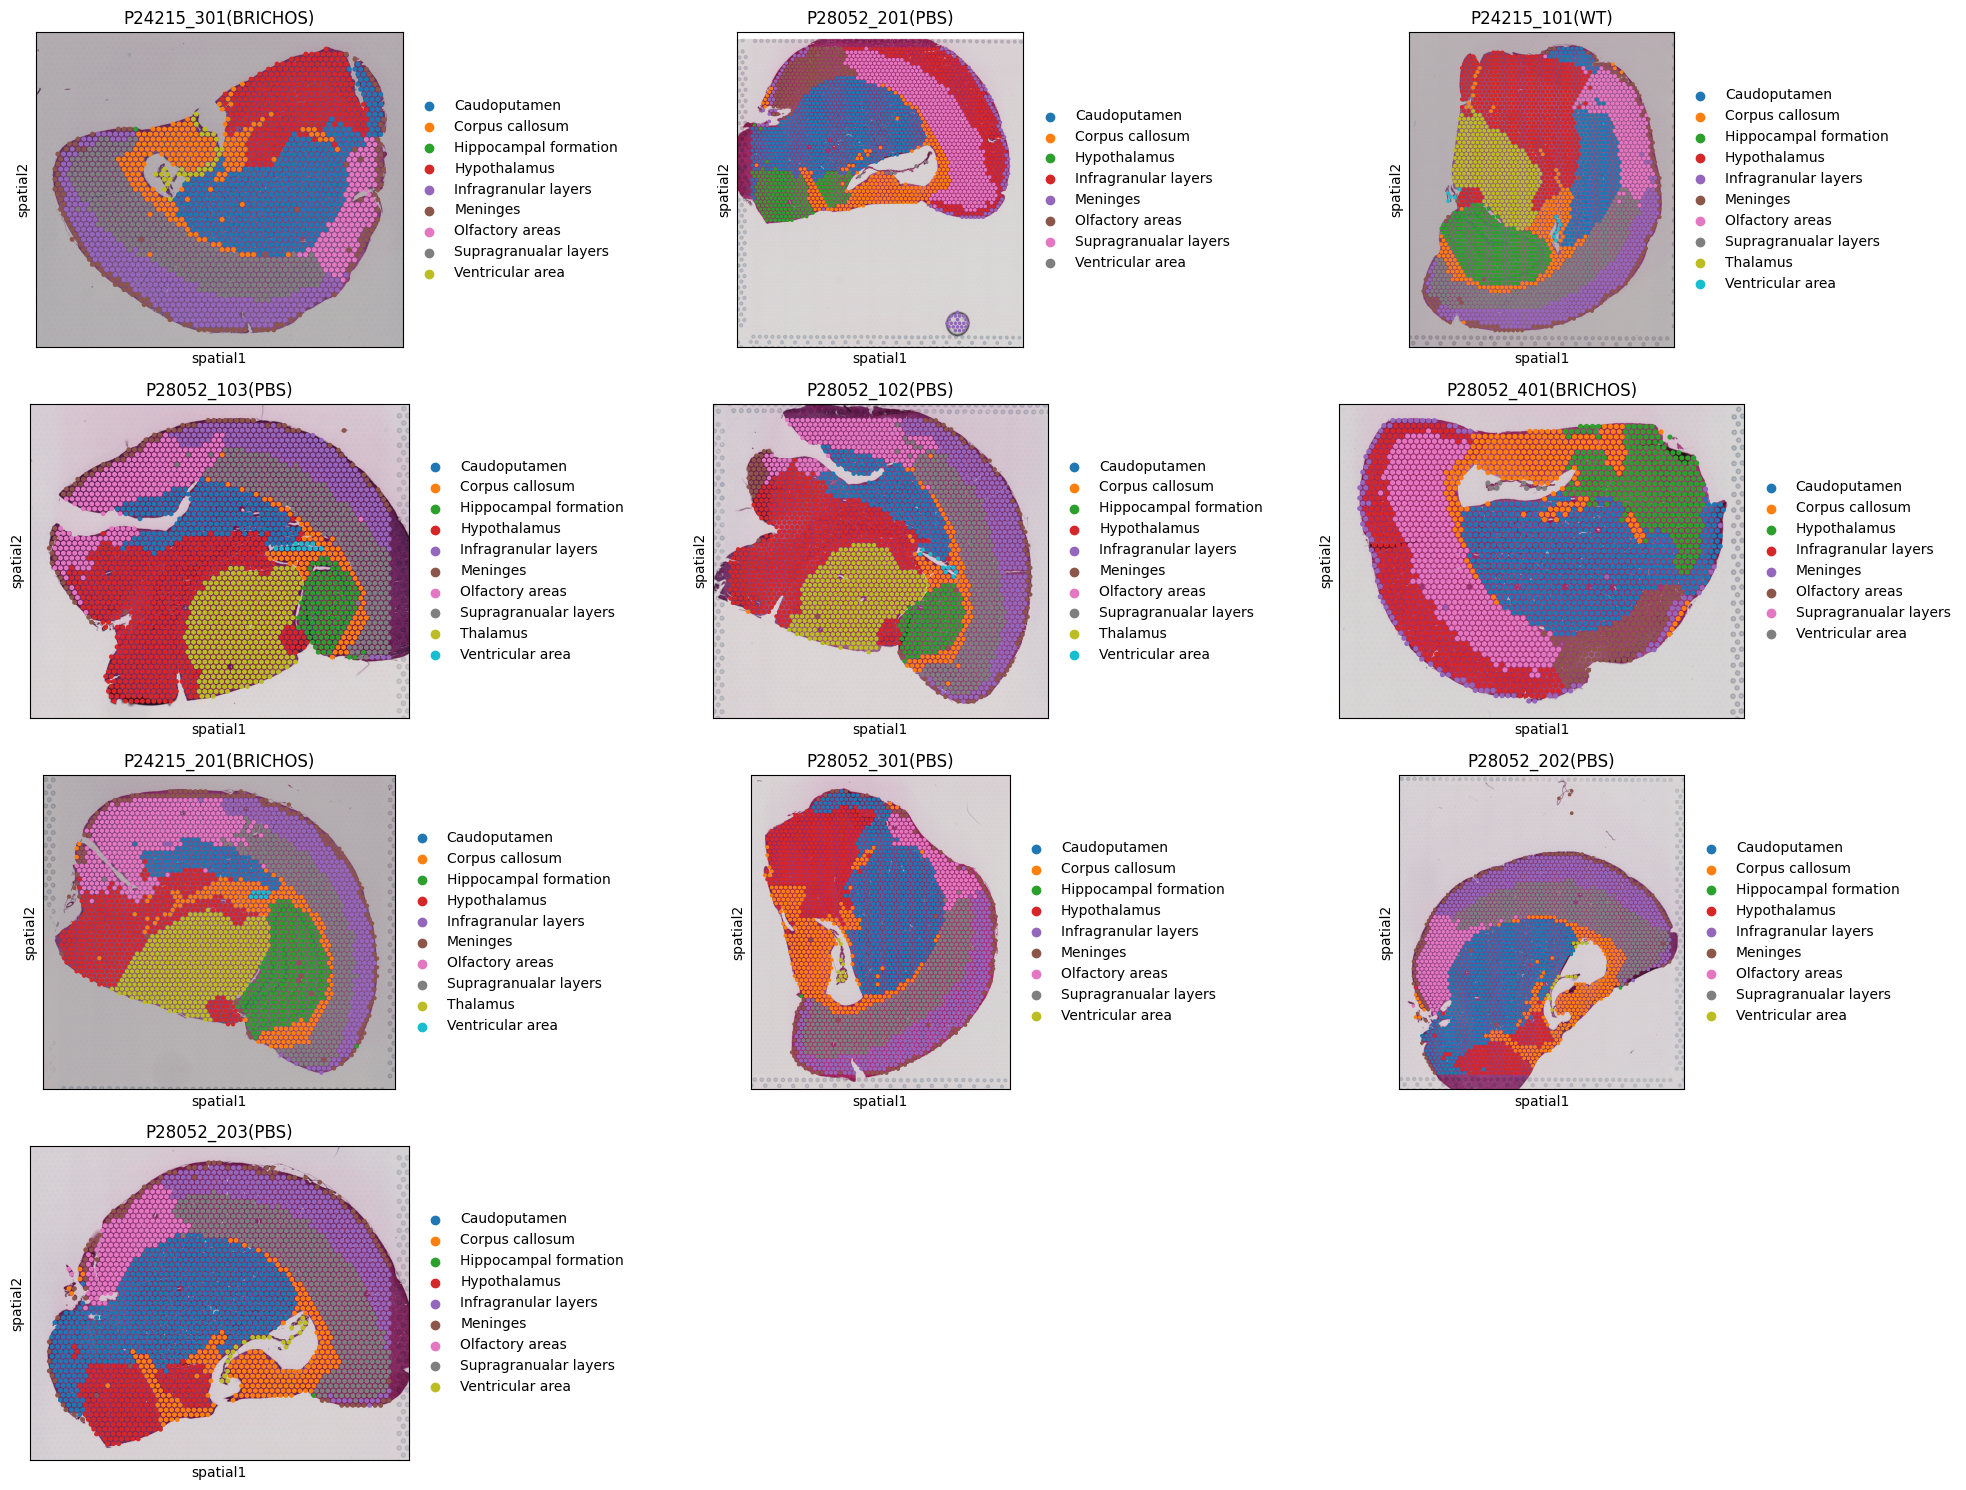

In [27]:
plot_spatial_clusters_per_sample(adata, color = 're_annotation_regions', figsize=(20,15))

In [38]:
region_to_genes = {
    "Thalamus": [
        # Complement & microglial activation
        "C1qa", "C1qb", "C1qc", "C1ql3", "C4b", "Clu", "C3ar1", "Cd74", "Ctss", "Ctsb", "Tyrobp", "Trem2",
        # Oxidative / stress response
        "Gpx3", "Mt1", "Mt2", "Hmox1", "Gadd45b", "Hspb1",
        # Astrocytic / metabolic
        "Serpina3n", "Gfap", "Vim", "Aldh1l1", "Apoe",
        # Interferon / cytokine signaling
        "Irf7", "Stat1", "Ifit3", "Oasl2", "Gbp2",
    ],
    "Ventricular area": [
        # Secreted stress mediators (mitokine-like)
        "Gdf15", "Adm", "Igfbp3", "Trib3", "Cdkn1a", "Ddit3", "Atf5", "Fgf21",
        # Immune / inflammatory
        "Cst7", "C4b", "Cd74", "H2-D1", "Serpina3n", "Lgals3bp", "Hmox1",
        # Metabolic adaptation
        "Aldh1l2", "Slc16a1", "Hk2", "Eno2", "Maff",
        # Structural / matrix remodeling
        "Vim", "Gfap", "Timp1", "Col1a1", "Fn1",
    ],
}

categories: Caudoputamen, Corpus callosum, Hippocampal formation, etc.
var_group_labels: Thalamus, Ventricular area


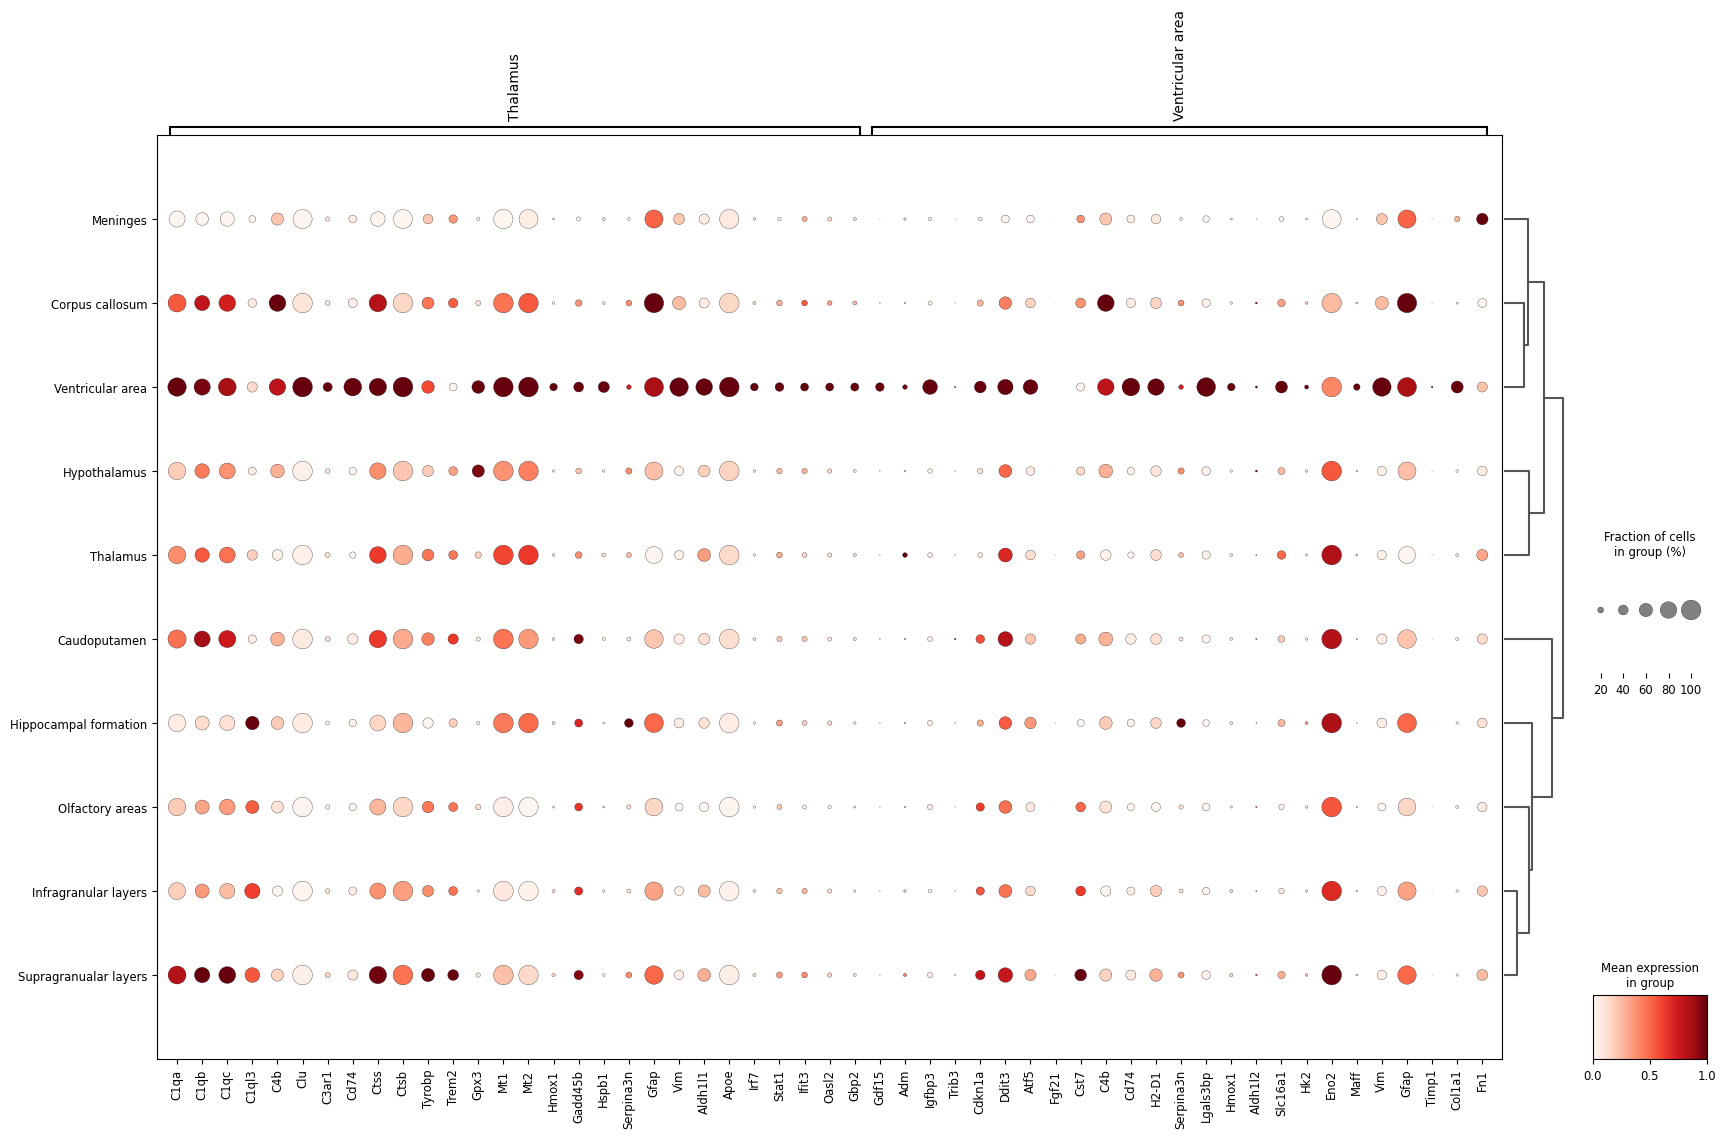

In [41]:
sc.pl.dotplot(
        adata,
        var_names=region_to_genes,
        groupby="re_annotation_regions",
        standard_scale="var",
        #dot_max=0.5,
        #dot_min=0.05,
        color_map="Reds",
        dendrogram=True,
        figsize=(20, 12),
        #categories_order=['Ctrl','Early','Peak','Late'],
    )

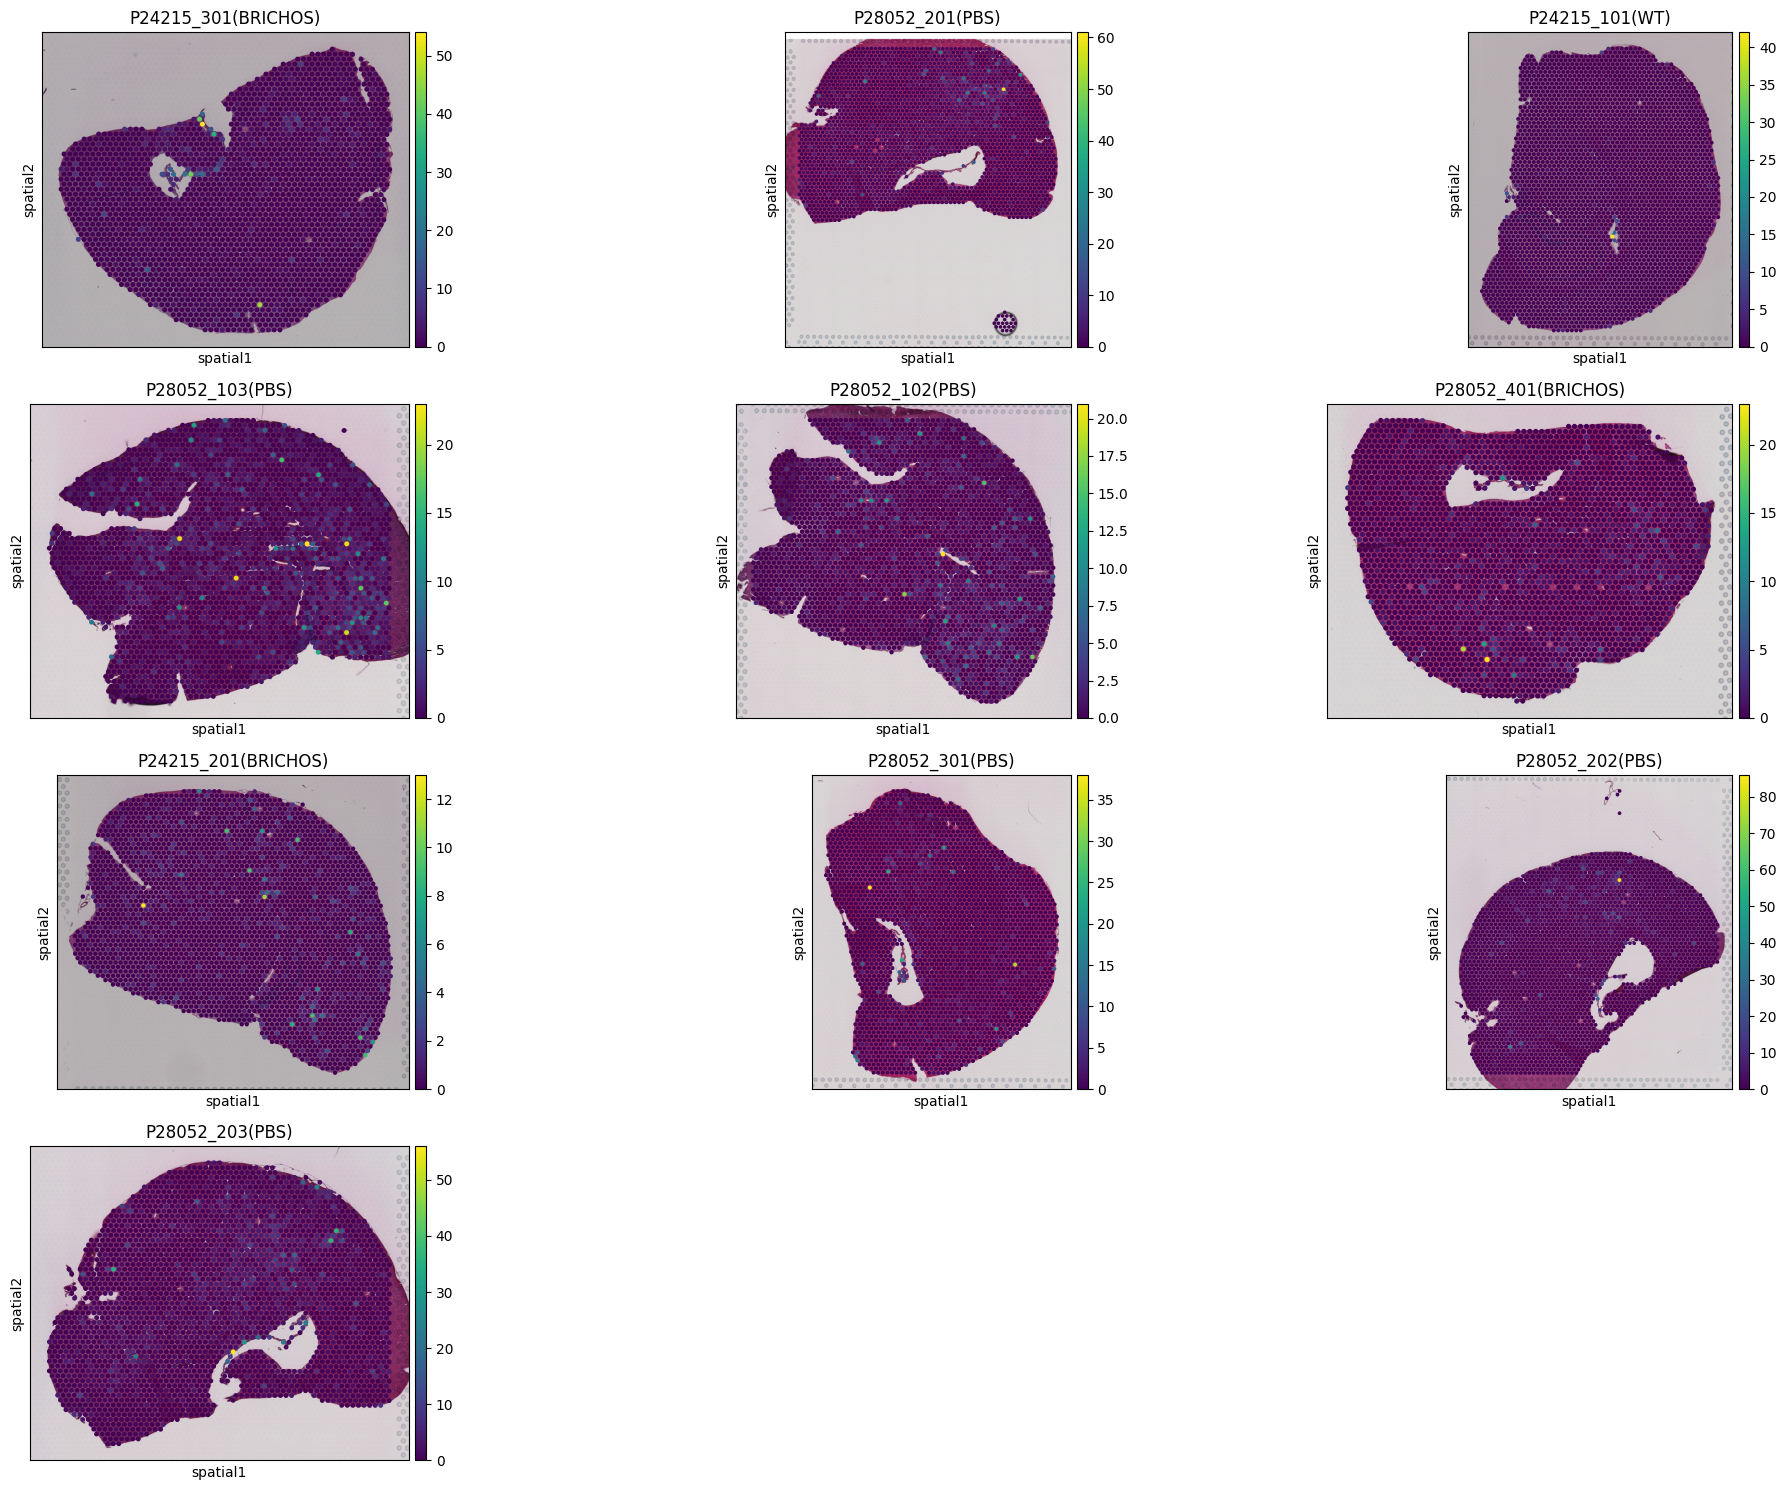

In [44]:
plot_spatial_clusters_per_sample(adata, color = 'Cd74', figsize=(20,15))